# Task 1: Exploratory Data Analysis (EDA)

In [1]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, levene
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 123

# -------------------------------------------------------------------
# Portable project paths
# -------------------------------------------------------------------
# This notebook may be started from the project root, notebooks folder,
# or the Kang Bin notebook folder itself.
# Locate the Cookiecutter project root automatically so the notebook
# continues to work after the project is moved to another PC.

cur_dir = Path.cwd().resolve()
print("Current working directory:", cur_dir)


def locate_project_root(start_dir: Path) -> Path:
    search_roots = [start_dir, *start_dir.parents]

    for base in search_roots:
        # Identify the Cookiecutter project root
        if (
            (base / "pyproject.toml").exists()
            and (base / "data").is_dir()
            and (base / "notebooks").is_dir()
            and (base / "src").is_dir()
        ):
            return base

    raise FileNotFoundError(
        "Could not locate the IT3385_Team5_Assignment project root. "
        "Keep this notebook inside the ML project structure."
    )


PROJECT_ROOT = locate_project_root(cur_dir)

# Dataset location in the new Cookiecutter structure
DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Kang Bin"
    / "tech_mental_health_burnout.csv"
)

# Flask application location in the new Cookiecutter structure
APP_DIR = (
    PROJECT_ROOT
    / "src"
    / "team5_app"
    / "Kang Bin"
    / "employee_burnout_app"
)

FINAL_MODEL_PATH = APP_DIR / "employee_burnout_final_model"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_FILE)
print("Application directory:", APP_DIR)
print("Final model target:", FINAL_MODEL_PATH)
print("Pandas version:", pd.__version__)



Current working directory: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\notebooks\Kang Bin
Project root: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment
Dataset: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\data\raw\Kang Bin\tech_mental_health_burnout.csv
Application directory: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\src\team5_app\Kang Bin\employee_burnout_app
Final model target: C:\IT3385\IT3385_Env_class\notebooks\IT3385_Team5_Assignment\src\team5_app\Kang Bin\employee_burnout_app\employee_burnout_final_model
Pandas version: 2.1.4


## 1. Load Dataset

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset was not found at: {DATA_FILE}\n"
        'Expected location: Kang Bin/data/tech_mental_health_burnout.csv'
    )

df = pd.read_csv(DATA_FILE)
display(df.head())
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,5.9,5.1,6.1,5.9,2,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,6.3,5.2,1.1,7.1,1,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,8.4,5.9,6.2,5.1,0,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,7.0,3.2,5.3,6.9,6,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,5.6,2.4,3.9,7.3,2,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


Shape: (150000, 25)

Data types:


,dtype
age,int64
gender,object
job_role,object
experience_years,float64
company_size,object
work_mode,object
work_hours_per_week,float64
overtime_hours,float64
meetings_per_day,float64
deadlines_missed,int64


## 2. Data Validation

Before conducting the exploratory analysis, the dataset is checked for missing values and duplicate records to ensure data completeness.

In [3]:
print("Missing values per column:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Number of duplicate rows:", df.duplicated().sum())

Missing values per column:


,Missing Values
age,0
gender,0
job_role,0
experience_years,0
company_size,0
work_mode,0
work_hours_per_week,0
overtime_hours,0
meetings_per_day,0
deadlines_missed,0


Number of duplicate rows: 0


No missing values or duplicate records were found in the dataset. This indicates that the dataset is complete and does not require cleaning for missing or repeated observations before proceeding with further analysis.

## 3. Descriptive Statistics

In [4]:
print("Numerical variables:")
df.describe().T



Numerical variables:


,count,mean,std,min,25%,50%,75%,max
age,150000.0,38.025340,9.510609,22.0,30.0,38.0,46.0,54.0
experience_years,150000.0,5.055010,2.878602,0.0,3.0,5.0,7.0,18.5
work_hours_per_week,150000.0,47.007580,7.893310,30.0,42.0,47.0,52.0,84.0
overtime_hours,150000.0,6.127180,3.783618,0.0,3.0,6.0,9.0,24.0
meetings_per_day,150000.0,4.010893,1.978316,0.0,3.0,4.0,5.0,12.0
deadlines_missed,150000.0,1.284193,1.426264,0.0,0.0,1.0,2.0,5.0
job_satisfaction,150000.0,5.500248,1.956102,1.0,4.2,5.5,6.9,10.0
manager_support,150000.0,5.497537,1.956915,1.0,4.1,5.5,6.8,10.0
work_life_balance,150000.0,5.016357,1.948553,1.0,3.7,5.0,6.4,10.0
sleep_hours,150000.0,6.499120,1.192343,3.0,5.7,6.5,7.3,10.0


In [5]:
print("\nCategorical variables:")

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Categorical variables:

gender:
['Female' 'Male' 'Non-binary']

job_role:
['Backend Developer' 'Frontend Developer' 'DevOps' 'Data Scientist'
 'Software Engineer' 'Product Manager' 'QA Engineer' 'ML Engineer']

company_size:
['Large' 'Mid-size' 'MNC' 'Startup']

work_mode:
['Hybrid' 'Remote' 'Onsite']

burnout_level:
['Low' 'Moderate' 'High']


**Insight:** Employees work about 47 hours per week on average and sleep around 6.5 hours. Most employees have low burnout, while some variables such as work hours, overtime and screen time show high maximum values that may indicate potential outliers.

**Observation:** The `gender` variable contains three valid categories: Male, Female and Non-binary. All three categories will be retained during data cleansing and modelling because Non-binary is a valid observed category rather than a data-quality error. Removing it would unnecessarily discard 7,433 valid records (about 4.96% of the dataset), while PyCaret can handle categorical variables automatically as part of its preprocessing pipeline. Retaining all three categories therefore preserves more information and keeps the modelling dataset representative of the available data.

## 4. Outlier Detection

Potential outliers are examined for continuous numerical variables using the Interquartile Range (IQR) method. Continuous variables are selected because they contain a wider range of values, making unusually high or low observations more meaningful to identify.

In [6]:
continuous_cols = df.select_dtypes(include=np.number).columns

# Exclude binary/discrete indicator variables
continuous_cols = [
    col for col in continuous_cols
    if df[col].nunique() > 2 # Exclude binary variables
]

outlier_summary = []

for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, count, lower, upper])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["variable", "outlier_count", "lower_bound", "upper_bound"]
).sort_values("outlier_count", ascending=False)

display(outlier_df)

,variable,outlier_count,lower_bound,upper_bound
4,meetings_per_day,1811,0.00,8.00
15,anxiety_score,1246,1.30,7.70
9,sleep_hours,1073,3.30,9.70
14,stress_level,927,2.20,9.40
2,work_hours_per_week,752,27.00,67.00
17,burnout_score,748,-1.70,5.50
11,screen_time_hours,679,2.80,13.20
1,experience_years,537,-3.00,13.00
16,depression_score,395,-0.35,6.45
3,overtime_hours,112,-6.00,18.00


**Insight:** Most continuous variables contain few or no potential outliers. The highest number of outliers is observed in meetings_per_day, followed by anxiety_score and sleep_hours. As these values may represent genuine employee conditions rather than errors, they are retained for further analysis.



> **Note:** The IQR method defines potential outliers as values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`. These bounds are statistical thresholds, so the lower bound may sometimes be negative even when negative values do not exist in the dataset. Any observations outside these thresholds is flagged as a potential outlier for further investigation.

## 5. Exploratory Data Analysis

Exploratory Data Analysis is performed to investigate the distributions, correlations, trends and relationships among workplace, lifestyle and mental-health variables, with particular focus on employee burnout.

### 5.1 Distribution of Burnout Level

The distribution of the target variable `burnout_level` is examined to determine the proportion of employees in each burnout category and identify whether the target classes are balanced.

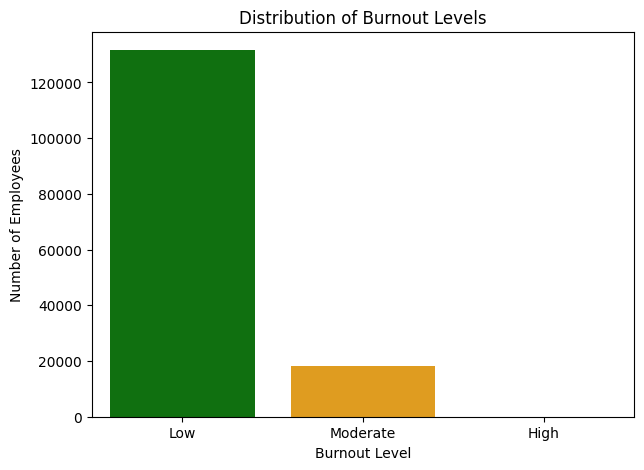

,Percentage (%)
burnout_level,
Low,87.75
Moderate,12.21
High,0.04


In [7]:
burnout_order = ['Low', 'Moderate', 'High']

palette = {
    'Low': 'green',
    'Moderate': 'orange',
    'High': 'red'
}

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='burnout_level',
    order=burnout_order,
    hue='burnout_level',
    palette=palette,
    legend=False
)

plt.title('Distribution of Burnout Levels')
plt.xlabel('Burnout Level')
plt.ylabel('Number of Employees')
plt.show()

# Percentage distribution
target_pct = (
    df['burnout_level']
    .value_counts(normalize=True)
    .reindex(burnout_order)
    .mul(100)
    .round(2)
)

display(target_pct.to_frame('Percentage (%)'))

**Insight:** The target variable is highly imbalanced, with 87.75% of employees classified as Low burnout, 12.21% as Moderate and only 0.04% as High. This imbalance should be considered when interpreting patterns involving the High burnout group and later when evaluating the classification model.

### 5.2 Distribution of Numerical Features

The distributions of key numerical variables are examined to understand their spread, shape and concentration, and to identify any skewness or unusual patterns before analysing relationships between variables.

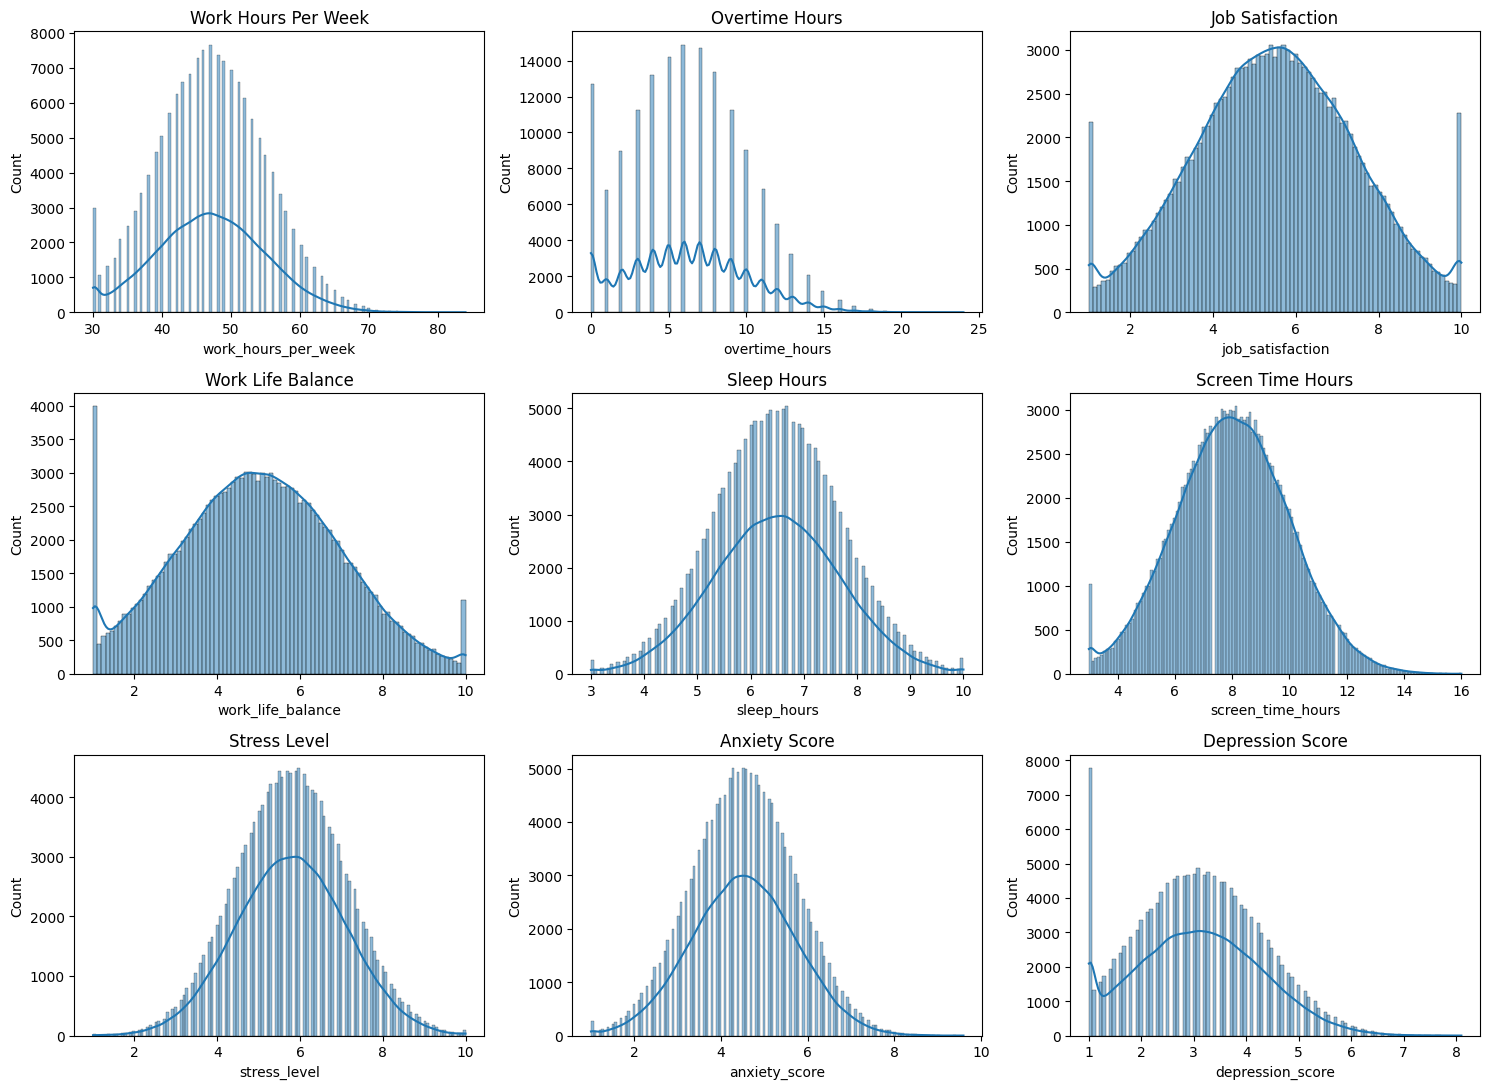

In [8]:
distribution_cols = [
    'work_hours_per_week',
    'overtime_hours',
    'job_satisfaction',
    'work_life_balance',
    'sleep_hours',
    'screen_time_hours',
    'stress_level',
    'anxiety_score',
    'depression_score'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, distribution_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax
    )

    ax.set_title(col.replace('_', ' ').title())

plt.tight_layout()
plt.show()

**Insight:** Most numerical features are concentrated around their central values, with several variables showing approximately bell-shaped distributions. `overtime_hours` and `depression_score` appear more right-skewed, indicating that most employees have lower values while a smaller number experience much higher levels.

### 5.3 Correlation Analysis

A correlation analysis is conducted to investigate the strength and direction of relationships among numerical variables.

Burnout level mapping: Low = 0, Moderate = 1, High = 2


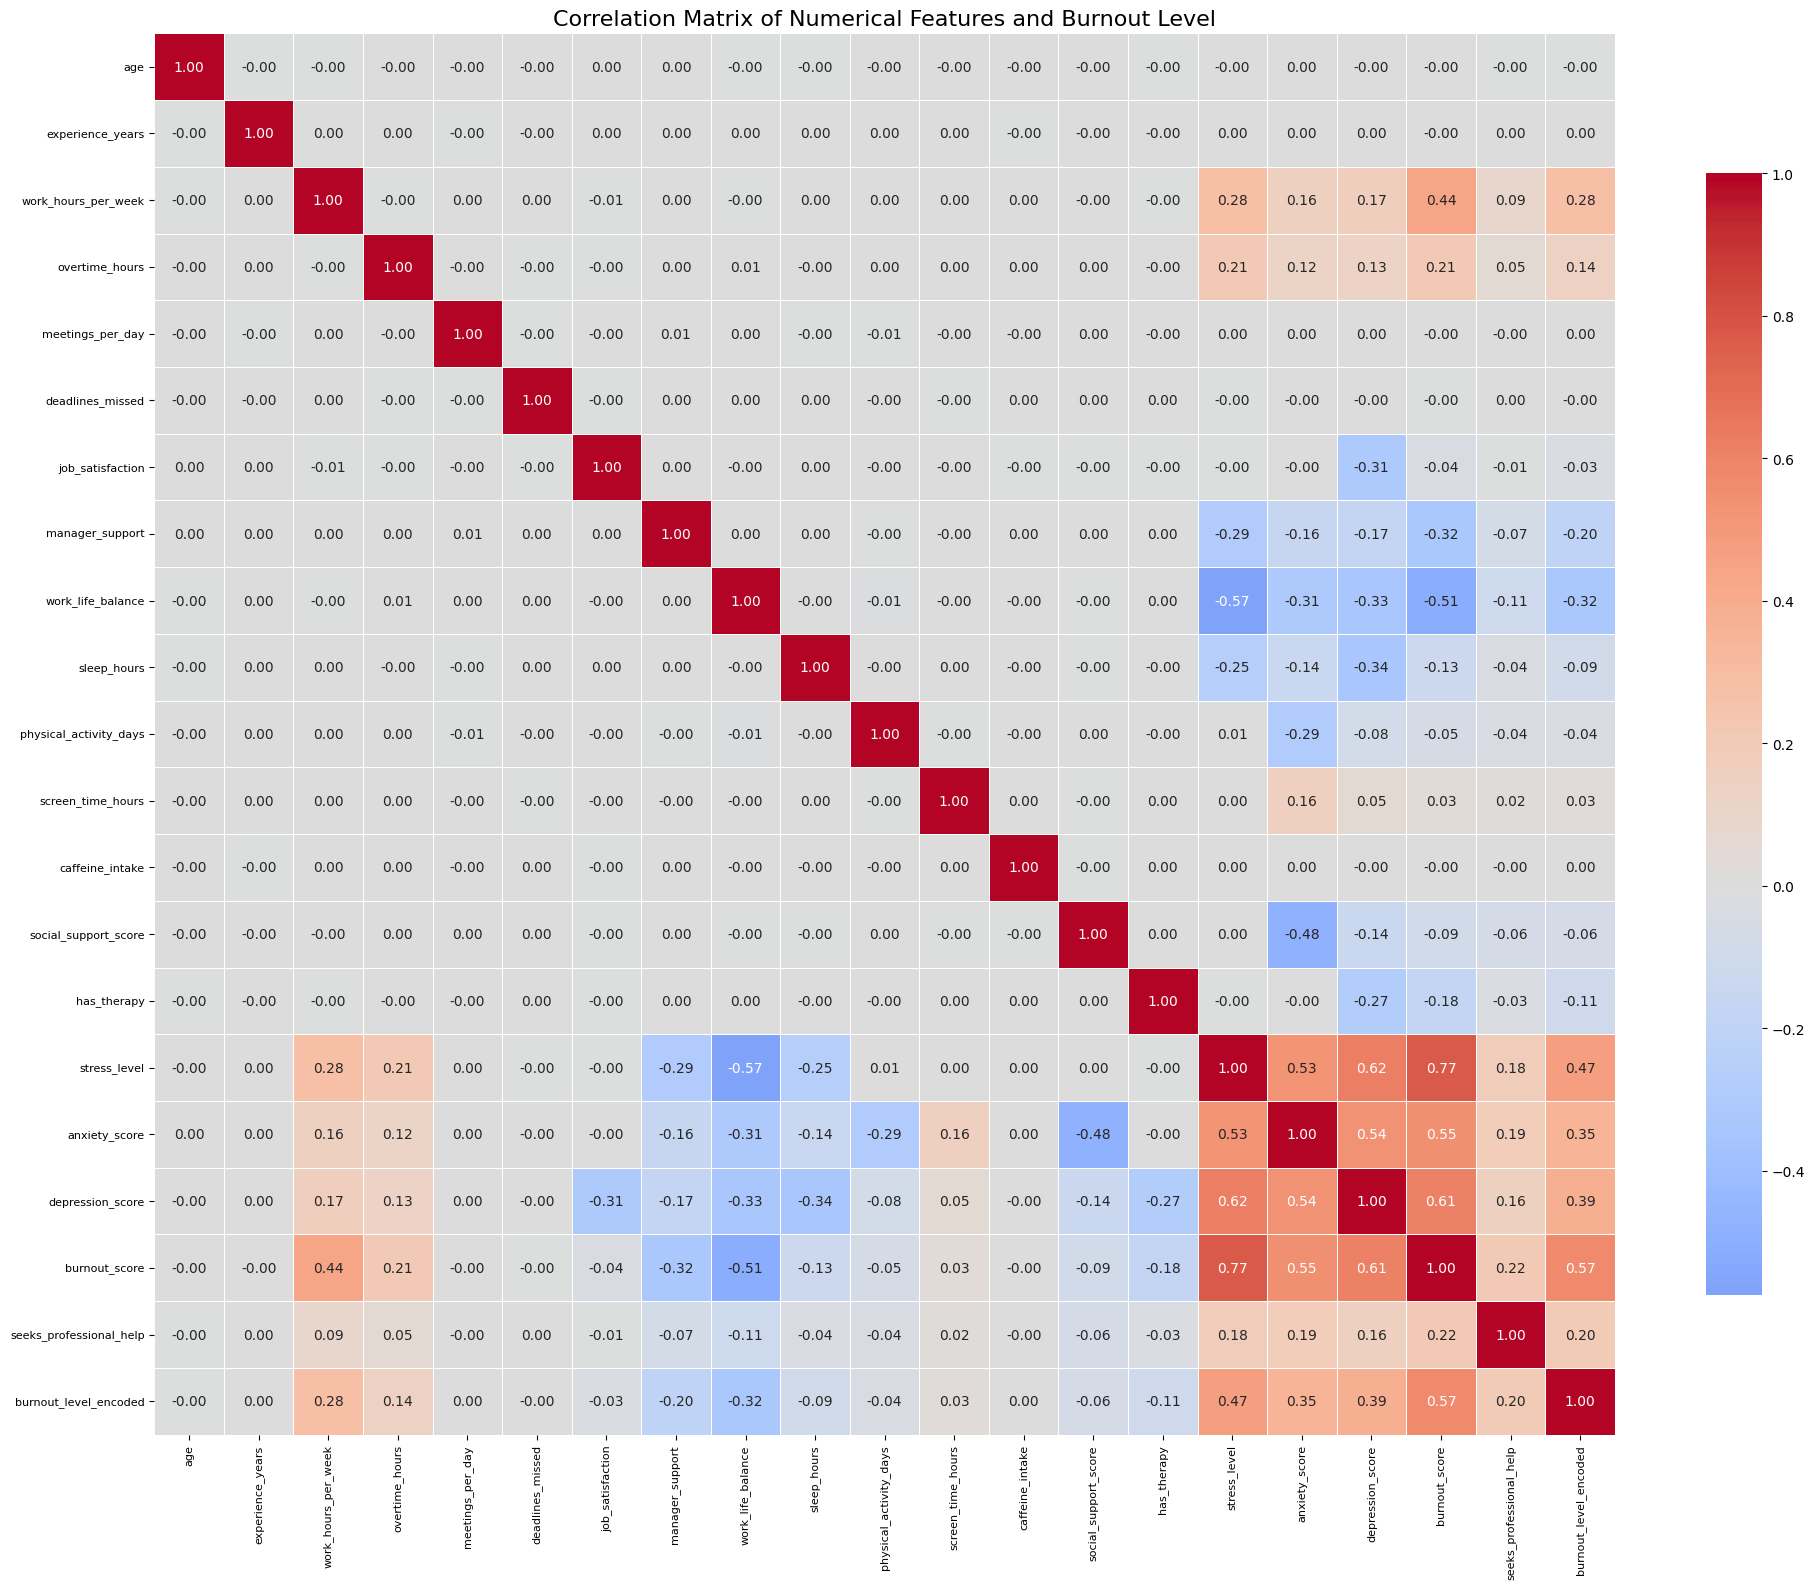


Temporary burnout_level_encoded column dropped.


In [9]:
# ============================================
# TEMPORARY: ENCODE BURNOUT LEVEL FOR CORRELATION
# ============================================

# Temporarily convert burnout level to ordinal values
df["burnout_level_encoded"] = df["burnout_level"].map({
    "Low": 0,
    "Moderate": 1,
    "High": 2
})

print("Burnout level mapping: Low = 0, Moderate = 1, High = 2")

# Get all numerical columns, including encoded target
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr(method="spearman")

# Plot correlation heatmap
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features and Burnout Level", fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Remove temporary encoded column after analysis
df.drop(columns=["burnout_level_encoded"], inplace=True)

print("\nTemporary burnout_level_encoded column dropped.")

- **Insight:** No severe multicollinearity is observed among the predictor variables, as none show extremely high pairwise correlations. The target `burnout_level` is most positively associated with `burnout_score` (0.57), followed by `stress_level` (0.47), `depression_score` (0.39) and `anxiety_score` (0.35). `work_life_balance` shows the strongest negative relationship with burnout level (-0.32), suggesting that better work-life balance is associated with lower burnout severity. Work hours also show a positive relationship with burnout (0.28).

- **Target Leakage Consideration:** `burnout_score` has the strongest relationship with `burnout_level` and is also strongly related to stress, anxiety and depression. It should therefore be investigated to determine whether `burnout_level` was derived directly from `burnout_score`. If so, `burnout_score` should be excluded from the model features to prevent target leakage and overly optimistic model performance.

### 5.4 Investigation of Potential Target Leakage

Since `burnout_score` showed the strongest correlation with the target, its distribution across burnout levels is examined to determine whether it may directly define the target categories.

In [10]:
burnout_order = ['Low', 'Moderate', 'High']

burnout_score_summary = (
    df.groupby('burnout_level')['burnout_score']
      .agg(['count', 'min', 'max', 'mean', 'median'])
      .reindex(burnout_order)
)

display(burnout_score_summary)

,count,min,max,mean,median
burnout_level,,,,,
Low,131620,1.0,3.5,1.815136,1.7
Moderate,18315,3.6,6.5,4.245804,4.1
High,65,6.6,8.1,6.893846,6.8


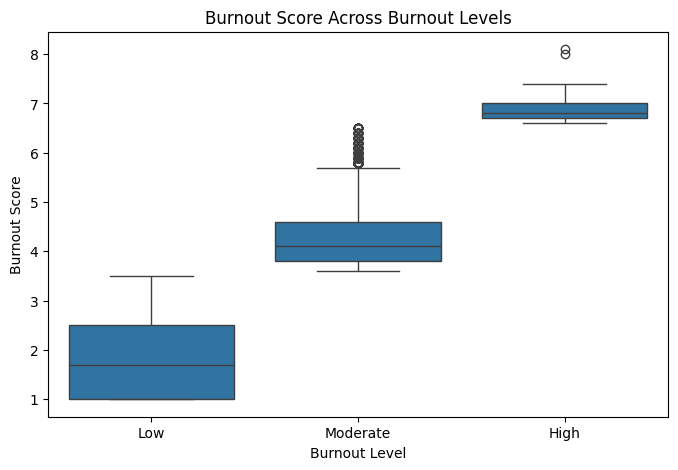

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='burnout_level',
    y='burnout_score',
    order=burnout_order
)

plt.title('Burnout Score Across Burnout Levels')
plt.xlabel('Burnout Level')
plt.ylabel('Burnout Score')

plt.show()

**Insight:** `burnout_score` shows complete separation across the three burnout levels, with no overlap between their score ranges. This strongly suggests that `burnout_level` was derived from `burnout_score`. Therefore, `burnout_score` will be excluded from the predictor variables during model development to prevent target leakage and overly optimistic model performance.

### 5.5 Key Numerical Patterns Across Burnout Levels

Key workplace and mental-health features are visualised across burnout levels to identify patterns and changes associated with increasing burnout severity.

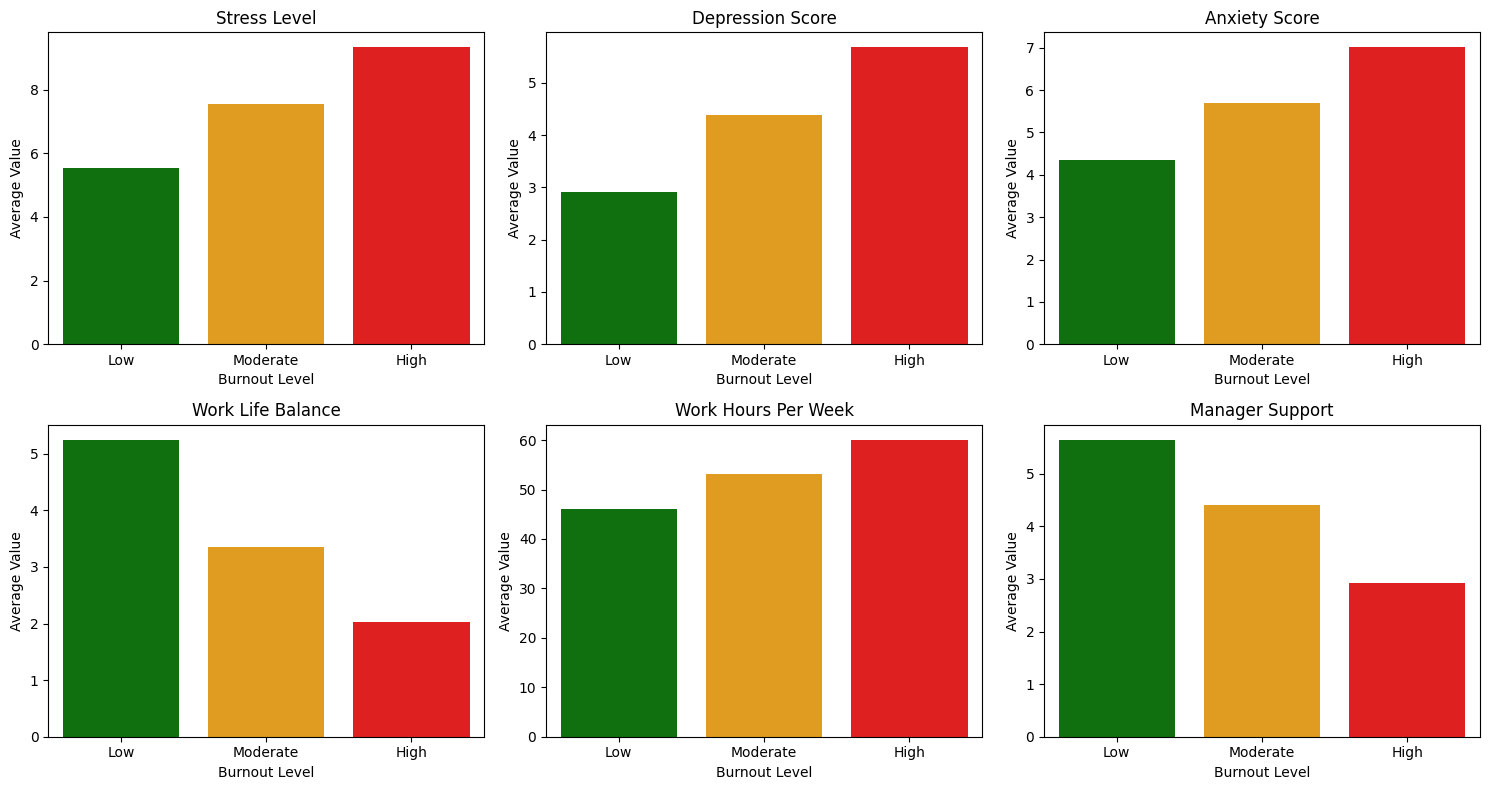

In [12]:
features = [
    'stress_level',
    'depression_score',
    'anxiety_score',
    'work_life_balance',
    'work_hours_per_week',
    'manager_support'
]

palette = {
    'Low': 'green',
    'Moderate': 'orange',
    'High': 'red'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.barplot(
        data=df,
        x='burnout_level',
        y=col,
        order=burnout_order,
        hue='burnout_level',
        palette=palette,
        errorbar=None,
        legend=False,
        ax=ax
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Burnout Level')
    ax.set_ylabel('Average Value')

plt.tight_layout()
plt.show()

**Insight:** Burnout tends to increase alongside three main patterns. Employees with higher burnout generally work longer hours, report lower work-life balance and manager support, and also show higher stress, anxiety and depression scores. Overall, heavier workloads, weaker workplace support and poorer mental health appears to be associated with greater burnout.

### 5.6 Workplace Characteristics and Burnout

Burnout levels are compared across different workplace characteristics to identify whether work mode, company size and job role are associated with different burnout patterns.

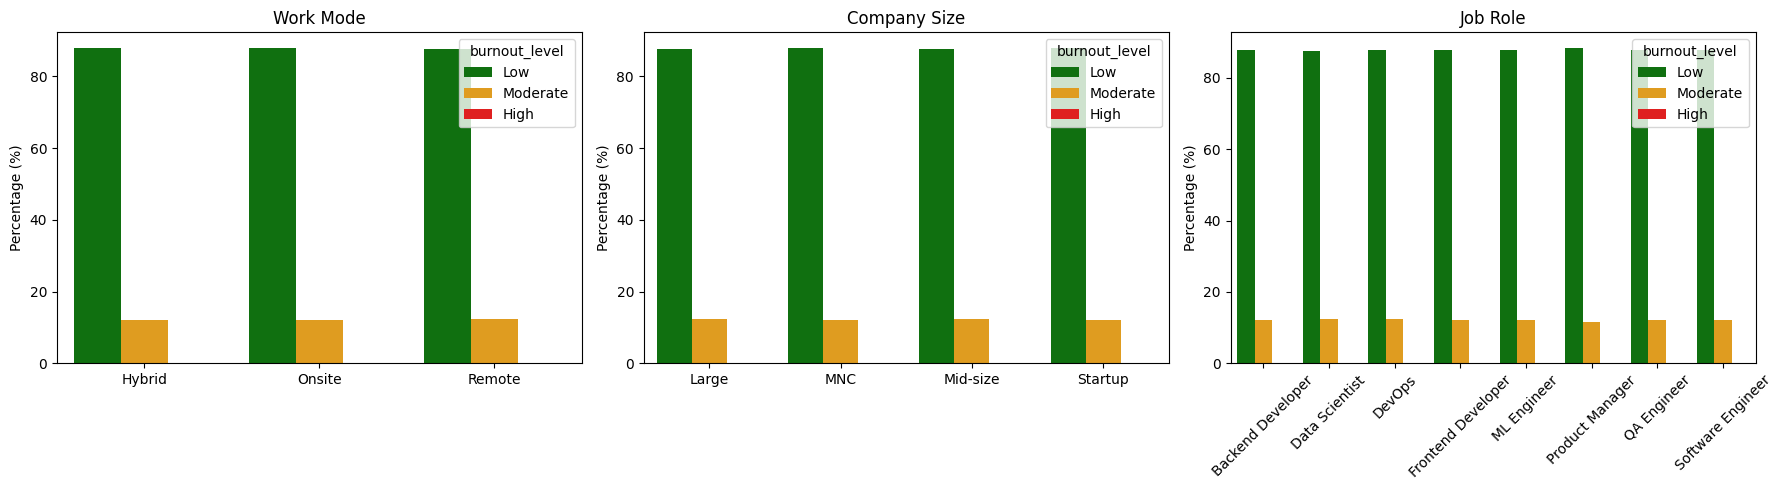

In [13]:
workplace_cols = ['work_mode', 'company_size', 'job_role']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, workplace_cols):

    # Convert counts into percentages within each category
    pct_df = (
        pd.crosstab(df[col], df['burnout_level'], normalize='index')
        .mul(100)
        .reset_index()
        .melt(
            id_vars=col,
            var_name='burnout_level',
            value_name='Percentage'
        )
    )

    sns.barplot(
        data=pct_df,
        x=col,
        y='Percentage',
        hue='burnout_level',
        hue_order=burnout_order,
        palette={
            'Low': 'green',
            'Moderate': 'orange',
            'High': 'red'
        },
        ax=ax
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')

axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight:** Burnout patterns are very similar across work mode, company size and job role. In all groups, the large majority of employees fall under Low burnout, while Moderate and High burnout proportions remain relatively small. This suggests that these workplace characteristics alone may not have a strong association with burnout compared with factors such as workload, workplace support and mental health.

### 5.7 Demographic Characteristics and Burnout

Age, gender and work experience are examined to determine whether burnout patterns differ across employee demographic groups.

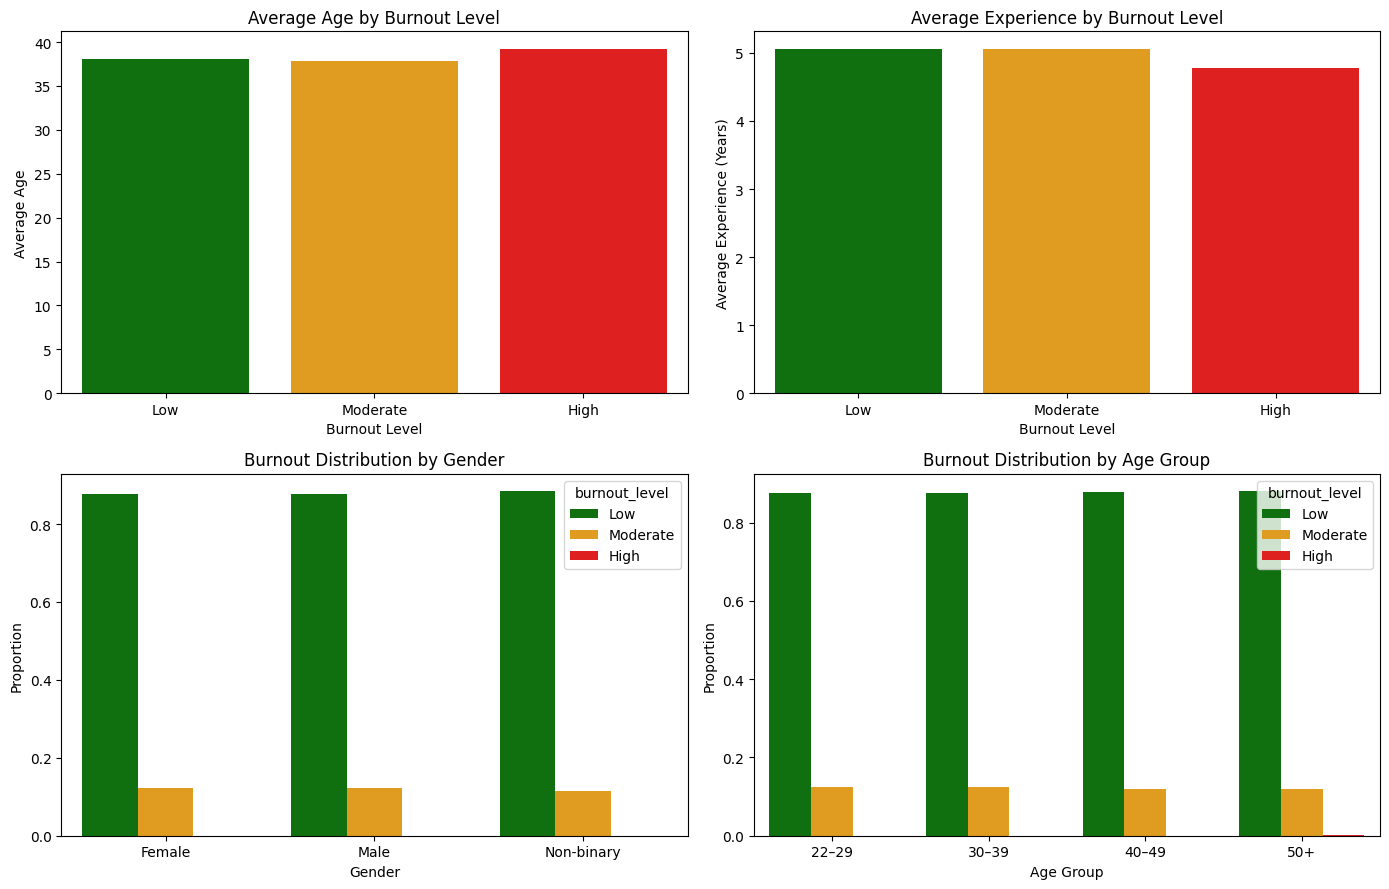

In [14]:
# Create a temporary dataframe for demographic analysis
demo_df = df.copy()

# Create age groups
demo_df['age_group'] = pd.cut(
    demo_df['age'],
    bins=[21, 29, 39, 49, 60],
    labels=['22–29', '30–39', '40–49', '50+']
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Average age across burnout levels
sns.barplot(
    data=demo_df,
    x='burnout_level',
    y='age',
    order=burnout_order,
    hue='burnout_level',
    palette=palette,
    errorbar=None,
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Average Age by Burnout Level')
axes[0, 0].set_xlabel('Burnout Level')
axes[0, 0].set_ylabel('Average Age')

# Average experience across burnout levels
sns.barplot(
    data=demo_df,
    x='burnout_level',
    y='experience_years',
    order=burnout_order,
    hue='burnout_level',
    palette=palette,
    errorbar=None,
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Average Experience by Burnout Level')
axes[0, 1].set_xlabel('Burnout Level')
axes[0, 1].set_ylabel('Average Experience (Years)')

# Burnout proportions by gender
gender_prop = (
    pd.crosstab(demo_df['gender'], demo_df['burnout_level'], normalize='index')
    .reindex(columns=burnout_order)
    .reset_index()
    .melt(
        id_vars='gender',
        var_name='burnout_level',
        value_name='proportion'
    )
)

sns.barplot(
    data=gender_prop,
    x='gender',
    y='proportion',
    hue='burnout_level',
    hue_order=burnout_order,
    palette=palette,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Burnout Distribution by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Proportion')

# Burnout proportions by age group
age_prop = (
    pd.crosstab(demo_df['age_group'], demo_df['burnout_level'], normalize='index')
    .reindex(columns=burnout_order)
    .reset_index()
    .melt(
        id_vars='age_group',
        var_name='burnout_level',
        value_name='proportion'
    )
)

sns.barplot(
    data=age_prop,
    x='age_group',
    y='proportion',
    hue='burnout_level',
    hue_order=burnout_order,
    palette=palette,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Burnout Distribution by Age Group')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

**Insight:** Burnout distributions are very similar across gender and age groups, suggesting that demographic characteristics have relatively weak associations with burnout. Average age and work experience also remain fairly consistent across burnout levels, although the High burnout group appears slightly older and less experienced. However, this pattern should be interpreted cautiously because the High burnout class contains very few employees.

### 5.8 Lifestyle and Support Factors Across Burnout Levels

Lifestyle and support-related factors are compared across burnout levels to identify patterns associated with increasing burnout severity.

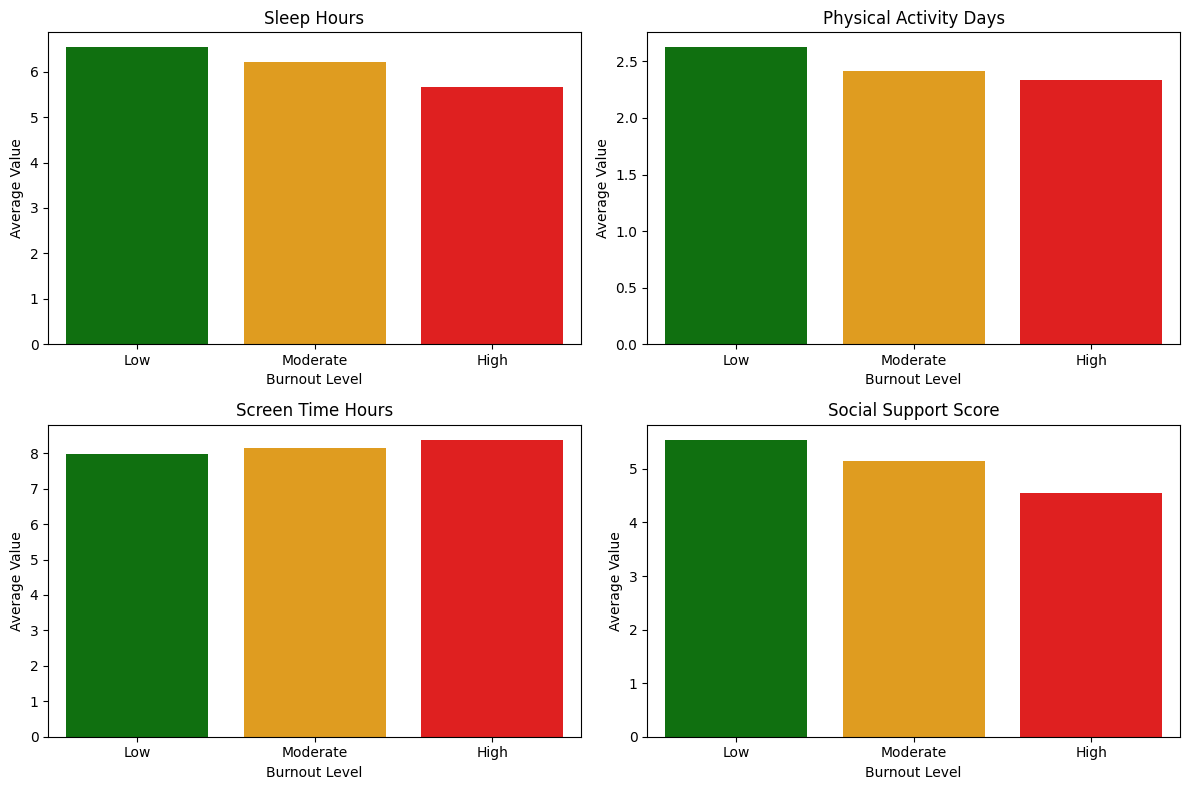

In [15]:
lifestyle_features = [
    'sleep_hours',
    'physical_activity_days',
    'screen_time_hours',
    'social_support_score'
]

palette = {
    'Low': 'green',
    'Moderate': 'orange',
    'High': 'red'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, lifestyle_features):
    sns.barplot(
        data=df,
        x='burnout_level',
        y=col,
        order=burnout_order,
        hue='burnout_level',
        palette=palette,
        errorbar=None,
        legend=False,
        ax=ax
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Burnout Level')
    ax.set_ylabel('Average Value')

plt.tight_layout()
plt.show()

**Lifestyle Insight:** As burnout increases, employees tend to sleep less, exercise slightly less and report lower social support, while screen time increases. This suggests that poorer lifestyle habits and lower social support are associated with higher burnout.

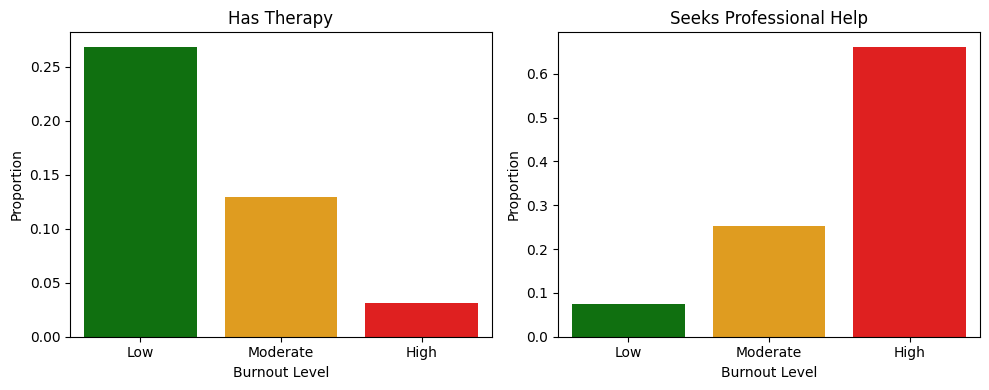

In [16]:
support_features = [
    'has_therapy',
    'seeks_professional_help'
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, support_features):
    sns.barplot(
        data=df,
        x='burnout_level',
        y=col,
        order=burnout_order,
        hue='burnout_level',
        palette=palette,
        errorbar=None,
        legend=False,
        ax=ax
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Burnout Level')
    ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

**Support Insight:** An interesting pattern appears in help-seeking behaviour. Employees with Low burnout are more likely to already be in therapy, which may suggest that ongoing support is associated with lower burnout levels. In contrast, employees with High burnout are much more likely to seek professional help, indicating that help-seeking tends to increase once burnout becomes more severe.

### 5.9 Multivariate Pattern Analysis

Work hours and stress levels are examined together across burnout categories to identify whether higher workload and stress show a combined pattern with employee burnout.

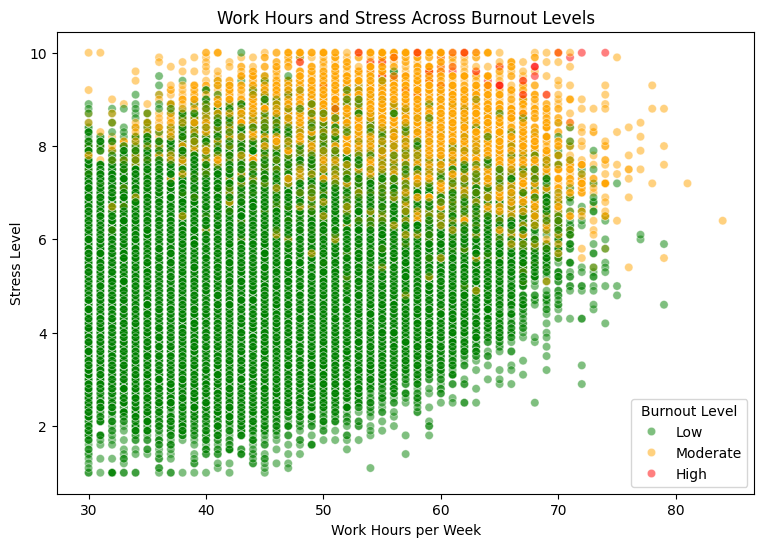

In [17]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='work_hours_per_week',
    y='stress_level',
    hue='burnout_level',
    hue_order=burnout_order,
    palette={
        'Low': 'green',
        'Moderate': 'orange',
        'High': 'red'
    },
    alpha=0.5
)

plt.title('Work Hours and Stress Across Burnout Levels')
plt.xlabel('Work Hours per Week')
plt.ylabel('Stress Level')
plt.legend(title='Burnout Level')

plt.show()

**Insight:** A clear combined pattern can be seen between workload, stress and burnout. Employees with higher burnout generally appear in the region with both longer work hours and higher stress levels, while Low burnout employees are more widely spread across lower stress levels. This suggests that higher workload together with higher stress is associated with greater burnout severity.

### 5.10 EDA Summary

The EDA reveals that higher burnout is associated with longer working hours, poorer work-life balance and manager support, and higher stress, anxiety and depression. Lifestyle factors such as reduced sleep and social support also show patterns with increasing burnout, while employees with severe burnout are more likely to seek professional help. In contrast, work mode, company size, job role and gender show relatively similar burnout distributions.

The target variable is highly imbalanced, and `burnout_score` was identified as a potential source of target leakage. The three valid gender categories — Male, Female and Non-binary — will all be retained for modelling because they are valid observations and PyCaret can preprocess categorical variables directly. These findings guide the data cleansing, transformation and modelling decisions in Task 2.

# Task 2: Train, Validate and Develop a Machine Learning Pipeline using PyCaret

A multiclass classification pipeline is developed using PyCaret to predict employee `burnout_level`. Findings from the EDA are used to guide data cleansing and preprocessing decisions before model training and evaluation.

> **Run note:** This Task 2 workflow retains all valid gender categories (**Male, Female and Non-binary**) and uses the logical target encoding **Low = 0, Moderate = 1, High = 2**. Because retaining the Non-binary records changes the modelling dataset, run Task 2 from the beginning so that the split, PyCaret setup, model comparison, tuning, evaluation, final predictions, saved pipeline and MLflow registration are all regenerated consistently.

## 1. Data Cleansing and Preparation

The EDA confirmed that the dataset contains no missing values or duplicate records. Therefore, no additional treatment is required for these issues.

For model development, a separate copy of the dataset is created. All three valid gender categories are retained, `burnout_score` is removed to prevent target leakage, plausible outliers are retained, and the target variable is logically encoded according to burnout severity for clearer model interpretation.

This approach avoids removing valid observations without a data-quality reason while still applying the cleansing and transformation decisions identified during EDA.

In [18]:
# Create a separate copy for modelling
model_df = df.copy()

print("Before data preparation")
print("-----------------------")
print("Dataset shape:", model_df.shape)

print("\nGender categories:")
print(model_df['gender'].value_counts())

print("\nColumns:")
print(model_df.columns.tolist())

Before data preparation
-----------------------
Dataset shape: (150000, 25)

Gender categories:
gender
Male          82286
Female        60281
Non-binary     7433
Name: count, dtype: int64

Columns:
['age', 'gender', 'job_role', 'experience_years', 'company_size', 'work_mode', 'work_hours_per_week', 'overtime_hours', 'meetings_per_day', 'deadlines_missed', 'job_satisfaction', 'manager_support', 'work_life_balance', 'sleep_hours', 'physical_activity_days', 'screen_time_hours', 'caffeine_intake', 'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score', 'depression_score', 'burnout_score', 'burnout_level', 'seeks_professional_help']


### 1.1 Gender Category Validation and Retention

The EDA identified three valid categories in `gender`: **Male, Female and Non-binary**.

All three categories are retained for modelling. Non-binary is a valid observed category rather than a missing, duplicated or erroneous value, so removing it would unnecessarily discard **7,433 records (about 4.96% of the full dataset)**. PyCaret can automatically preprocess categorical variables, so a binary Male/Female restriction is not required for the machine-learning pipeline.

The code below validates that only the expected gender categories are present and confirms that no records are removed at this stage.

In [19]:
# Validate the gender categories without removing any valid records
expected_gender_categories = {'Male', 'Female', 'Non-binary'}
observed_gender_categories = set(model_df['gender'].dropna().unique())
unexpected_gender_categories = observed_gender_categories - expected_gender_categories

if unexpected_gender_categories:
    raise ValueError(
        f"Unexpected gender categories found: {sorted(unexpected_gender_categories)}"
    )

# Summarise the retained categories
gender_summary = model_df['gender'].value_counts().to_frame('Count')
gender_summary['Percentage (%)'] = (
    gender_summary['Count'] / len(model_df) * 100
).round(2)

print('Gender categories retained for modelling:')
display(gender_summary)

print(f"Total records retained: {len(model_df):,}")
print('Records removed due to gender category: 0')

Gender categories retained for modelling:


,Count,Percentage (%)
gender,,
Male,82286,54.86
Female,60281,40.19
Non-binary,7433,4.96


Total records retained: 150,000
Records removed due to gender category: 0


### 1.2 Target Leakage Removal

The EDA showed that `burnout_score` has a direct relationship with `burnout_level`, with the burnout categories occupying separate score ranges. This indicates potential target leakage.

Therefore, `burnout_score` is removed before model training to prevent the model from using information that directly determines the target.

In [20]:
print("Before leakage removal:")
print("burnout_score present:", 'burnout_score' in model_df.columns)
print("Number of columns:", model_df.shape[1])

# Remove target leakage variable
model_df.drop(columns=['burnout_score'], inplace=True)

print("\nAfter leakage removal:")
print("burnout_score present:", 'burnout_score' in model_df.columns)
print("Number of columns:", model_df.shape[1])

Before leakage removal:
burnout_score present: True
Number of columns: 25

After leakage removal:
burnout_score present: False
Number of columns: 24


### 1.3 Outlier Treatment

Potential outliers identified during EDA are retained because they fall within plausible employee ranges and are not confirmed data-entry errors.

Removing these observations may eliminate meaningful cases, especially employees experiencing more extreme workplace or mental-health conditions. Robust scaling will later be used in the PyCaret preprocessing pipeline to reduce the influence of extreme numerical values.

In [21]:
print("Final dataset after preparation")
print("--------------------------------")
print("Original shape:", df.shape)
print("Prepared shape:", model_df.shape)

print("\nGender categories:")
print(model_df['gender'].unique())

print("\nburnout_score present:",
      'burnout_score' in model_df.columns)

print("\nTarget distribution before encoding:")
print(model_df['burnout_level'].value_counts())

Final dataset after preparation
--------------------------------
Original shape: (150000, 25)
Prepared shape: (150000, 24)

Gender categories:
['Female' 'Male' 'Non-binary']

burnout_score present: False

Target distribution before encoding:
burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64


### 1.4 Target Variable Encoding

The `burnout_level` target variable is manually encoded according to increasing burnout severity to provide a clear and intuitive representation of the three classes during modelling and evaluation.

- **Low = 0**
- **Moderate = 1**
- **High = 2**

The encoded values remain **class labels** for the multiclass classification problem. The numerical order is used only to make outputs such as confusion matrices and classification reports easier to interpret; the values are not treated as continuous burnout scores.

In [22]:
# Encode burnout level according to increasing severity
burnout_mapping = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}

model_df['burnout_level'] = (
    model_df['burnout_level']
    .map(burnout_mapping)
    .astype(int)
)

# Reverse mapping used later to display readable class names
burnout_labels = {
    0: 'Low',
    1: 'Moderate',
    2: 'High'
}

print("Burnout level encoding:")
print("0 = Low")
print("1 = Moderate")
print("2 = High")

print("\nEncoded target distribution:")
print(
    model_df['burnout_level']
    .value_counts()
    .sort_index()
)

Burnout level encoding:
0 = Low
1 = Moderate
2 = High

Encoded target distribution:
burnout_level
0    131620
1     18315
2        65
Name: count, dtype: int64


### 1.5 Reserve Unseen Data for Final Prediction

Before model development, 10% of the prepared dataset is reserved as unseen data.

The remaining 90% is used as the development dataset and will be passed to PyCaret. PyCaret will automatically split this development dataset into its own training and holdout test sets during `setup()`.

The unseen dataset is kept completely separate from model training, cross-validation, hyperparameter tuning and holdout evaluation. It will only be used after the final model has been selected and finalised to generate predictions using `predict_model`.

In [23]:
from sklearn.model_selection import train_test_split

# Reserve 10% of the prepared data as completely unseen data
development_data, unseen_data = train_test_split(
    model_df,
    test_size=0.10,
    random_state=123,
    stratify=model_df['burnout_level']
)

print("Class mapping: 0 = Low, 1 = Moderate, 2 = High")
print("Development data shape:", development_data.shape)
print("Unseen data shape:", unseen_data.shape)

print("\nDevelopment data class counts:")
print(development_data['burnout_level'].value_counts().sort_index())

print("\nDevelopment data class distribution (%):")
print(
    development_data['burnout_level']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(4)
)

print("\nUnseen data class counts:")
print(unseen_data['burnout_level'].value_counts().sort_index())

print("\nUnseen data class distribution (%):")
print(
    unseen_data['burnout_level']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(4)
)

Class mapping: 0 = Low, 1 = Moderate, 2 = High
Development data shape: (135000, 24)
Unseen data shape: (15000, 24)

Development data class counts:
burnout_level
0    118458
1     16483
2        59
Name: count, dtype: int64

Development data class distribution (%):
burnout_level
0    87.7467
1    12.2096
2     0.0437
Name: proportion, dtype: float64

Unseen data class counts:
burnout_level
0    13162
1     1832
2        6
Name: count, dtype: int64

Unseen data class distribution (%):
burnout_level
0    87.7467
1    12.2133
2     0.0400
Name: proportion, dtype: float64


## 2. Data Transformation and PyCaret Setup

PyCaret is used to prepare the development dataset and set up the machine learning environment for burnout classification.

After retaining all 150,000 valid records and reserving 10% as completely unseen data, the development dataset contains **135,000 records**. The preprocessing pipeline is kept focused so that it remains reproducible and computationally manageable.

Robust scaling is applied to numerical features, while related mental-health and workplace-support variables are grouped together for additional feature engineering. PyCaret also handles categorical preprocessing, including the three retained gender categories, within the transformation pipeline.

The target remains a three-class multiclass problem using the logical labels **0 = Low, 1 = Moderate and 2 = High**. Since the classes are highly imbalanced, stratified sampling is used to maintain a similar class distribution during training and cross-validation.

### 2.1 Runtime and MLflow Configuration

CPU usage is limited to four cores to reduce multiprocessing overhead on Windows and improve processing stability when working with the large dataset.

The local MLflow tracking server is configured **before** PyCaret `setup()` so that experiment activity generated during model training is recorded in the `employee_burnout_classification` experiment. This directly enables experiment logging during model development while keeping the final model registration as a separate, clearly named MLflow run later in the workflow.


In [24]:
import os

# Reduce Git-related warnings
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

# Limit CPU usage to reduce multiprocessing overhead
# when processing the large dataset
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import pycaret
import mlflow

# Connect PyCaret/MLflow logging to the local MLflow tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Create or select the experiment used throughout model development
mlflow.set_experiment("employee_burnout_classification")

print("PyCaret version:", pycaret.__version__)
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow experiment: employee_burnout_classification")


2026/08/21 22:57:10 INFO mlflow.tracking.fluent: Experiment with name 'employee_burnout_classification' does not exist. Creating a new experiment.


PyCaret version: 3.3.2
MLflow tracking URI: http://127.0.0.1:5000
MLflow experiment: employee_burnout_classification


### 2.2 Class Imbalance

The EDA shows that the burnout target is highly imbalanced across the full prepared dataset:

- **Low (0): approximately 87.75%**
- **Moderate (1): approximately 12.21%**
- **High (2): approximately 0.04%**

Only **65 High burnout records** are present in the complete 150,000-record dataset, so the exact number available in the development split remains very small. The stratified split printed above shows the class counts used for model development and final unseen evaluation.

For the initial model comparison, the original class distribution is retained without automatic oversampling. With so few real High-burnout observations, aggressive synthetic oversampling could create artificial patterns and increase overfitting risk. Stratified splitting and stratified k-fold cross-validation are therefore used to preserve the observed distribution.

Because the minority classes are much smaller, overall metrics are interpreted together with class-level Precision, Recall, F1-score, MCC and confusion matrices rather than relying on Accuracy alone. Hyperparameter tuning is then used to determine whether alternative model settings, including any class-weight configuration explored by the tuner, improve cross-validated performance.

### 2.3 Initialise the PyCaret Pipeline and Enable MLflow Experiment Logging

PyCaret is configured using an 80:20 training and holdout split.

Stratified sampling is used to maintain the class distribution during data splitting and cross-validation. Robust scaling is applied to numerical features, while related mental-health and workplace-support variables are grouped to generate additional features.

Three-fold cross-validation is used during the initial model comparison to reduce training time. More detailed validation is then performed on the selected model.

MLflow experiment logging is enabled in `setup()` using `log_experiment='mlflow'` and `experiment_name='employee_burnout_classification'`. Therefore, model-development activities performed by PyCaret are recorded in MLflow during training, while the final selected pipeline is logged and registered separately after unseen-data evaluation.


In [25]:
from pycaret.classification import *

burnout_exp = setup(
    data=development_data,
    target='burnout_level',

    # Reproducibility
    session_id=123,

    # Training and holdout split
    train_size=0.80,
    data_split_stratify=True,

    # Numerical scaling
    normalize=True,
    normalize_method='robust',

    # Feature engineering
    group_features={
        'mental_health_scores': [
            'stress_level',
            'anxiety_score',
            'depression_score'
        ],

        'support_scores': [
            'job_satisfaction',
            'manager_support',
            'work_life_balance',
            'social_support_score'
        ]
    },

    # Stratified cross-validation
    fold_strategy='stratifiedkfold',
    fold=3,

    # Limit CPU usage
    n_jobs=4,

    # Enable MLflow experiment logging during model training
    log_experiment='mlflow',
    experiment_name='employee_burnout_classification',

    # Keep automatic plot logging disabled to reduce unnecessary overhead
    log_plots=False
)


,Description,Value
0,Session id,123
1,Target,burnout_level
2,Target type,Multiclass
3,Original data shape,"(135000, 24)"
4,Transformed data shape,"(135000, 50)"
5,Transformed train set shape,"(108000, 50)"
6,Transformed test set shape,"(27000, 50)"
7,Numeric features,19
8,Categorical features,4
9,Preprocess,True


Continuous-variable binning was not applied because the numerical features retain meaningful variation in their original continuous form. Discretising them unnecessarily could remove useful information; therefore, robust normalisation and grouped feature engineering were selected as the preprocessing techniques most appropriate for this dataset.

## 3. Model Training and Comparison

Several multiclass classification models are trained and compared to predict the three burnout levels: Low, Moderate and High.

A selected group of models is used to represent different machine learning approaches while keeping training time manageable for the large dataset.

The selected models are:

- Logistic Regression – linear classification model
- Random Forest – bagging-based ensemble model
- Extra Trees – randomised tree ensemble model
- LightGBM – gradient boosting model

The models are evaluated using **3-fold cross-validation**. Performance is reviewed across **Accuracy, AUC, Recall, Precision, F1-score, Kappa and MCC** to obtain a broader view of model quality.

The comparison table is ordered using MCC because the target is highly imbalanced, but the final baseline selection is interpreted across the full set of reported metrics rather than from a single score alone.

In [26]:
# Selected multiclass classification models
candidate_models = [
    'lr',        # Logistic Regression
    'rf',        # Random Forest
    'et',        # Extra Trees
    'lightgbm'   # LightGBM
]

# Compare models using 3-fold cross-validation.
# MCC orders the table because of class imbalance, while the final
# interpretation considers the complete set of reported metrics.
best_model = compare_models(
    include=candidate_models,
    sort='MCC',
    turbo=True
)

print("\nBest baseline model returned by the comparison:")
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9322,0.0000,0.9322,0.9283,0.9294,0.6605,0.6640,32.5233
lightgbm,Light Gradient Boosting Machine,0.9262,0.9519,0.9262,0.9260,0.9254,0.6389,0.6409,35.1000
rf,Random Forest Classifier,0.9248,0.9486,0.9248,0.9184,0.9192,0.6018,0.6122,36.7833
et,Extra Trees Classifier,0.9236,0.9492,0.9236,0.9169,0.9169,0.5868,0.6011,32.5567


2026/08/21 23:07:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 23:07:59 INFO mlflow.tracking._tracking_service.client: 🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/478235090601148638/runs/856b412ef2594aa2b593f1a3f5f217e8.
2026/08/21 23:07:59 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/478235090601148638.
2026/08/21 23:08:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 23:08:00 INFO mlflow.tracking._tracking_service.client: 🏃 View run Light Gradient Boosting Machine at: http://127.0.0.1:5000/#/experiments/478235090601148638/runs/ef546f609d424ae2921b36d6ab6ffa13.
2026/08/21 23:08:00 INFO mlflow.tracking._tracking_service.


Best baseline model returned by the comparison:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


### 3.1 Model Comparison Interpretation

The four candidate models were evaluated using **3-fold stratified cross-validation** and compared using Accuracy, AUC, Recall, Precision, F1-score, Kappa and Matthews Correlation Coefficient (MCC). As the target variable is highly imbalanced, **MCC was used as the main model-selection metric**, since it provides a more balanced assessment of classification performance than Accuracy alone.

Among the models, **Logistic Regression achieved the highest MCC of 0.6640**, together with the highest Accuracy of **0.9322**, F1-score of **0.9294**, Precision of **0.9283**, Recall of **0.9322**, and Kappa of **0.6605**. This indicates that Logistic Regression provided the strongest overall baseline performance across the evaluated metrics.

**LightGBM ranked second based on MCC, with a score of 0.6409**. Although its Accuracy of **0.9262** was slightly lower than Logistic Regression, it achieved the highest reported **AUC of 0.9519**. Random Forest and Extra Trees produced lower MCC values of **0.6122** and **0.6011**, respectively, indicating comparatively weaker overall classification performance.

The AUC value of **0.0000 reported for Logistic Regression should be interpreted cautiously**, as it is inconsistent with the model's strong performance across the other metrics and may be related to how AUC was calculated or supported for the multiclass configuration.

Therefore, **Logistic Regression is selected as the best baseline model and will be carried forward to the hyperparameter tuning stage**. However, further evaluation should still consider class-level performance, particularly for the rare High-burnout class, because strong overall scores may mask poor prediction performance for minority classes.

## 4. Hyperparameter Tuning

Hyperparameter tuning is performed on the selected baseline model to search for model settings that may improve its performance.

Only the selected model is tuned to reduce unnecessary training time on the large dataset. The tuning process uses **3-fold cross-validation** and evaluates **10 different hyperparameter combinations**.

Although the models were compared using multiple performance metrics in the previous section, the tuning algorithm requires a **single optimisation metric** to determine which hyperparameter combination performs best. **Matthews Correlation Coefficient (MCC)** is selected for this purpose because the burnout target is highly imbalanced.

MCC considers the overall agreement between the actual and predicted classes while accounting for correct and incorrect predictions across the multiclass problem. This makes it more informative than Accuracy alone when one class, particularly Low burnout, dominates the dataset.

Therefore, **MCC is used as the optimisation criterion during hyperparameter tuning**, while Accuracy, AUC, Precision, Recall, F1-score and Kappa are still reviewed when evaluating the selected model overall.

In [27]:
# Tune the best baseline model
tuned_model, tuner = tune_model(
    best_model,

    # 3-fold cross-validation
    fold=3,

    # Test 10 hyperparameter combinations
    n_iter=10,

    # Optimise using MCC
    optimize='MCC',

    # Keep the better-performing version
    choose_better=True,

    # Return tuning information
    return_tuner=True
)

print("\nTuned model:")
print(tuned_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9290,0.0000,0.9290,0.9250,0.9263,0.6462,0.6492
1,0.9335,0.0000,0.9335,0.9296,0.9306,0.6653,0.6693
2,0.9342,0.0000,0.9342,0.9304,0.9314,0.6702,0.6737
Mean,0.9322,0.0000,0.9322,0.9283,0.9294,0.6605,0.6641
Std,0.0023,0.0000,0.0023,0.0024,0.0022,0.0103,0.0107


Fitting 3 folds for each of 10 candidates, totalling 30 fits


2026/08/21 23:27:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 23:27:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/478235090601148638/runs/fe0bd497b46c47d3adb306d46371d8f9.
2026/08/21 23:27:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/478235090601148638.



Tuned model:
LogisticRegression(C=6.718000000000001, class_weight={}, dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


**Best Hyperparameters Found**

The tuning process searches for improved parameter values using cross-validation. The best hyperparameter combination identified during the search is displayed below.

In [28]:
# Display the best hyperparameters found
print("Best hyperparameters:")

for parameter, value in tuner.best_params_.items():
    print(f"{parameter}: {value}")

Best hyperparameters:
actual_estimator__class_weight: {}
actual_estimator__C: 6.718000000000001


### Hyperparameter Tuning Interpretation

The tuning process evaluates **10 candidate hyperparameter combinations using 3-fold cross-validation** and optimises them using **MCC**. The best parameter values identified were `C = 6.718` and `class_weight = {}`.

The tuned Logistic Regression achieved a mean **Accuracy of 0.9322**, **F1-score of 0.9294**, **Kappa of 0.6605**, and **MCC of 0.6641**. The relatively small MCC standard deviation of **0.0107** indicates that its performance was reasonably consistent across the three folds.

Compared with the original Logistic Regression baseline MCC of **0.6640**, the tuned result of **0.6641** represents only a negligible improvement. This suggests that the baseline model was already close to a suitable configuration.

`choose_better=True` ensures that PyCaret only returns the tuned candidate if it performs better than the original baseline according to MCC. The returned `tuned_model` is evaluated next on PyCaret's internal holdout set, where overall and class-level performance are examined.

## 5. Selected Model Evaluation

The tuned Logistic Regression model returned from the tuning stage is evaluated using the **internal holdout set** created during the PyCaret `setup()` process.

The holdout set is not used during cross-validation or hyperparameter search, so it provides an additional check of generalisation before the model is finalised. Overall metrics are interpreted together with class-level results because the burnout target is highly imbalanced.

In [29]:
# Evaluate tuned model on the internal PyCaret holdout set
holdout_predictions = predict_model(
    tuned_model,
    verbose=False
)

# Retrieve the holdout evaluation metrics
holdout_results = pull()

display(holdout_results)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9331,0.9637,0.9331,0.9291,0.9302,0.663,0.6672


### Holdout Performance Interpretation

The **tuned Logistic Regression model** was evaluated on PyCaret's internal holdout set and achieved an **Accuracy of 0.9331**, **Precision of 0.9291**, **Recall of 0.9331**, **F1-score of 0.9302**, **Kappa of 0.6630**, **MCC of 0.6672**, and **AUC of 0.9637**.

These results are highly consistent with the 3-fold cross-validation performance obtained during hyperparameter tuning, where the tuned model achieved an Accuracy of **0.9322**, F1-score of **0.9294**, Kappa of **0.6605**, and MCC of **0.6641**. The slightly higher holdout MCC of **0.6672** suggests that the tuned model maintains its performance on unseen data without showing substantial evidence of overfitting.

The strong AUC of **0.9637** also indicates good overall discrimination between the burnout classes on the holdout data. However, because the target distribution is highly imbalanced, these overall metrics alone are not sufficient to determine whether the tuned model performs well for every class.

Therefore, the confusion matrix and class-level classification report are examined next to assess whether the **tuned Logistic Regression model** can correctly identify the **Moderate** and particularly the rare **High-burnout** class.

### 5.1 Confusion Matrix

The confusion matrix compares the **actual burnout level** with the **predicted burnout level** on the internal PyCaret holdout set.

The logical target encoding is shown directly in the axis labels:

- **Low = 0**
- **Moderate = 1**
- **High = 2**

Values on the diagonal represent correct predictions, while values outside the diagonal represent misclassifications. This is particularly useful for checking whether the model can identify the less frequent Moderate and High burnout classes rather than mainly predicting the majority Low class.

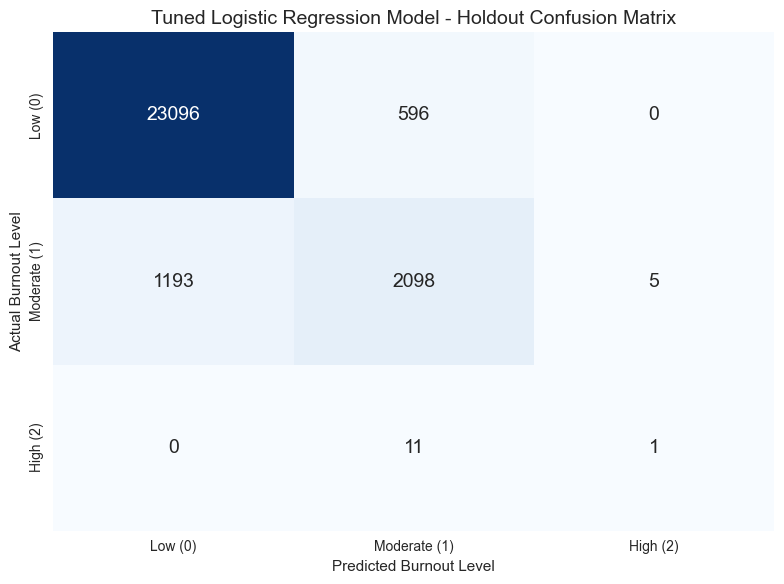

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Actual and predicted classes from the internal holdout set
# Predictions were generated using the tuned Logistic Regression model
y_holdout_actual = holdout_predictions['burnout_level'].astype(int)
y_holdout_pred = holdout_predictions['prediction_label'].astype(int)

class_order = [0, 1, 2]
class_names = ['Low (0)', 'Moderate (1)', 'High (2)']

# Compute confusion matrix for the tuned Logistic Regression model
cm_holdout = confusion_matrix(
    y_holdout_actual,
    y_holdout_pred,
    labels=class_order
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_holdout,
    annot=True,
    annot_kws={'size': 14},
    fmt='g',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    'Tuned Logistic Regression Model - Holdout Confusion Matrix',
    fontsize=14
)
plt.xlabel('Predicted Burnout Level')
plt.ylabel('Actual Burnout Level')

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the **tuned Logistic Regression model performs very strongly for the majority Low-burnout class**, correctly classifying **23,096 out of 23,692 Low-burnout cases**. Only **596 Low-burnout cases** were incorrectly classified as Moderate, giving the Low-burnout class a recall of approximately **97.5%**.

Performance for the **Moderate-burnout class is weaker but still meaningful**. The model correctly identified **2,098 out of 3,296 Moderate-burnout cases**, corresponding to a recall of approximately **63.7%**. Most Moderate-burnout errors occurred when **1,193 cases were incorrectly classified as Low burnout**, while only **5 cases** were incorrectly classified as High burnout.

The main limitation is the model's performance on the rare **High-burnout class**. Of the **12 actual High-burnout cases**, only **1 was correctly classified as High**, while **11 were classified as Moderate**. This corresponds to a High-burnout recall of only approximately **8.3%**. In addition, the model predicted only **6 cases as High burnout**, of which only one was correct.

Therefore, although the tuned Logistic Regression model achieves a high overall Accuracy of **93.31%** and strong overall MCC and F1-score, the confusion matrix shows that this performance is largely influenced by the dominant Low-burnout class. The model demonstrates reasonable discrimination for Moderate burnout but is currently **not reliable for identifying the extremely rare High-burnout class**.

This highlights why overall Accuracy alone is insufficient for this imbalanced multiclass problem. The class-level Precision, Recall and F1-scores are examined next to quantify these differences more clearly.

### 5.2 Classification Report

The classification report evaluates **Precision, Recall and F1-score separately for each burnout class**. This is important because the overall holdout metrics can hide weaker performance on the minority classes.

The class names are displayed using the logical mapping **Low (0), Moderate (1) and High (2)** for easier interpretation.

In [31]:
from sklearn.metrics import classification_report
import pandas as pd

# Create a readable class-level performance table
holdout_class_report = classification_report(
    y_holdout_actual,
    y_holdout_pred,
    labels=[0, 1, 2],
    target_names=['Low (0)', 'Moderate (1)', 'High (2)'],
    output_dict=True,
    zero_division=0
)

holdout_class_report_df = pd.DataFrame(
    holdout_class_report
).transpose()

display(holdout_class_report_df.round(4))

,precision,recall,f1-score,support
Low (0),0.9509,0.9748,0.9627,23692.0000
Moderate (1),0.7756,0.6365,0.6992,3296.0000
High (2),0.1667,0.0833,0.1111,12.0000
accuracy,0.9331,0.9331,0.9331,0.9331
macro avg,0.6311,0.5649,0.5910,27000.0000
weighted avg,0.9291,0.9331,0.9302,27000.0000


### Class-Level Performance Interpretation

The class-level results show a clear difference in performance across the three burnout classes.

For the **Low-burnout class**, the tuned Logistic Regression model performs very strongly, achieving a **Precision of 0.9509**, **Recall of 0.9748**, and **F1-score of 0.9627** across **23,692 samples**. This confirms that the model identifies the majority Low-burnout class reliably.

For the **Moderate-burnout class**, performance is noticeably weaker. The model achieved a **Precision of 0.7756**, **Recall of 0.6365**, and **F1-score of 0.6992** across **3,296 samples**. The lower Recall indicates that a substantial proportion of actual Moderate-burnout cases are still being missed, which is consistent with the confusion matrix where many Moderate cases were predicted as Low burnout.

The largest weakness is observed for the rare **High-burnout class**. The model achieved a **Precision of 0.1667**, **Recall of 0.0833**, and **F1-score of 0.1111** across only **12 samples**. This means that the tuned model identifies very few of the actual High-burnout cases correctly and is therefore not reliable for this minority class.

Although the overall Accuracy is high at **0.9331**, the **macro-average F1-score of 0.5910** is much lower than the **weighted-average F1-score of 0.9302**. This gap reflects the strong class imbalance, because the weighted score is dominated by the much larger Low-burnout class while the macro average gives equal importance to all three classes.

Therefore, the class-level evaluation confirms that the tuned Logistic Regression model performs well overall and very strongly for Low burnout, provides moderate performance for Moderate burnout, but remains weak at detecting the rare High-burnout class. This limitation should be considered when deciding whether the model is suitable for final deployment.

### 5.3 PyCaret Model Analysis

To retain PyCaret's built-in model-analysis workflow, the tuned model is also analysed using `plot_model`. The ROC/AUC plot provides a visual assessment of the model's ability to separate the classes on the internal holdout data.

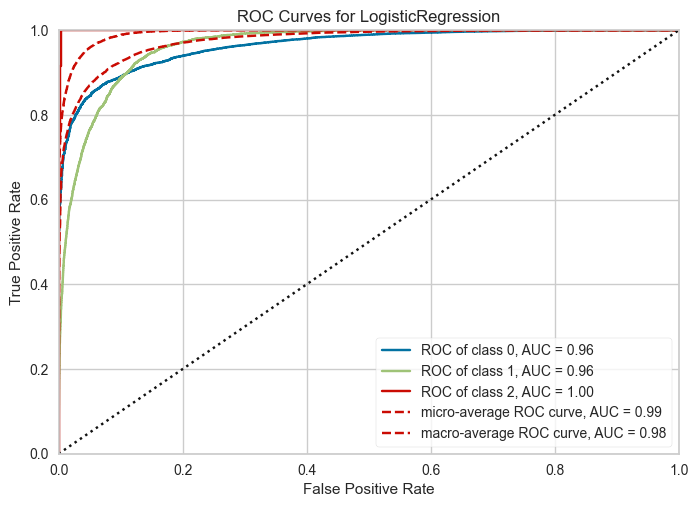

In [32]:
# PyCaret model-analysis plot on the internal holdout set
plot_model(
    tuned_model,
    plot='auc'
)

### ROC/AUC Interpretation

The ROC curves evaluate the ability of the **tuned Logistic Regression model** to distinguish each burnout class across different classification thresholds on the internal holdout set.

The model achieved an AUC of approximately **0.96 for Low burnout**, **0.96 for Moderate burnout**, and **1.00 for High burnout**. The overall **micro-average AUC is 0.99**, while the **macro-average AUC is 0.98**, indicating strong overall class-separation ability.

However, the **High-burnout AUC of 1.00 should be interpreted cautiously**. The holdout set contains only **12 High-burnout samples**, making the class-level AUC highly sensitive to the small sample size. Furthermore, the confusion matrix and classification report showed that only **1 of the 12 High-burnout cases was actually predicted correctly**, giving the class a Recall of only **0.0833**.

This apparent difference occurs because **AUC measures how well the model ranks or separates classes across all possible decision thresholds**, whereas the confusion matrix, Precision, Recall and F1-score evaluate predictions made using the model's selected classification decision. Therefore, a high AUC does not necessarily mean that the model successfully identifies the High-burnout class at its current decision boundary.

Overall, the ROC results suggest that the tuned Logistic Regression model has strong discrimination capability, but the poor Recall and F1-score for the rare High-burnout class remain an important limitation. For this highly imbalanced problem, the ROC/AUC results should therefore be interpreted together with MCC, the confusion matrix and class-level metrics rather than in isolation.

### 5.4 Verify MLflow Experiment Logging During Training

Because MLflow logging was enabled during PyCaret `setup()`, the experiment should contain runs produced during model development. The following check retrieves the experiment logs so that the training-stage MLflow tracking can be verified directly before the final model is trained and registered.


In [33]:
# Retrieve MLflow experiment logs created during PyCaret model development
training_experiment_logs = get_logs(
    experiment_name='employee_burnout_classification'
)

print("Number of MLflow experiment log records:", len(training_experiment_logs))
display(training_experiment_logs.tail(10))


Number of MLflow experiment log records: 6


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.Kappa,metrics.AUC,metrics.MCC,metrics.TT,...,tags.mlflow.source.type,tags.mlflow.user,tags.mlflow.source.name,tags.Run ID,tags.USI,tags.mlflow.parentRunId,tags.mlflow.runName,tags.mlflow.log-model.history,tags.Source,tags.URI
0,fe0bd497b46c47d3adb306d46371d8f9,478235090601148638,FINISHED,mlflow-artifacts:/478235090601148638/fe0bd497b...,2026-08-21 15:27:33.344000+00:00,2026-08-21 15:27:35.475000+00:00,0.6605,0.0000,0.6641,89.7600,...,LOCAL,Kang Bin,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,fe0bd497b46c47d3adb306d46371d8f9,0bf4,bf6434ef331142e498fc5b709feba9fb,Logistic Regression,"[{""run_id"": ""fe0bd497b46c47d3adb306d46371d8f9""...",tune_model,ad7adf65
1,025a18ed99774a948f4f2c9774f1b448,478235090601148638,FINISHED,mlflow-artifacts:/478235090601148638/025a18ed9...,2026-08-21 15:08:02.539000+00:00,2026-08-21 15:08:03.586000+00:00,0.5868,0.9492,0.6011,32.5567,...,LOCAL,Kang Bin,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,025a18ed99774a948f4f2c9774f1b448,0bf4,bf6434ef331142e498fc5b709feba9fb,Extra Trees Classifier,"[{""run_id"": ""025a18ed99774a948f4f2c9774f1b448""...",compare_models,30371e1d
2,9a5c362c6b17406787d6717a2defefd8,478235090601148638,FINISHED,mlflow-artifacts:/478235090601148638/9a5c362c6...,2026-08-21 15:08:01.155000+00:00,2026-08-21 15:08:02.083000+00:00,0.6018,0.9486,0.6122,36.7833,...,LOCAL,Kang Bin,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,9a5c362c6b17406787d6717a2defefd8,0bf4,bf6434ef331142e498fc5b709feba9fb,Random Forest Classifier,"[{""run_id"": ""9a5c362c6b17406787d6717a2defefd8""...",compare_models,36acd6f3
3,ef546f609d424ae2921b36d6ab6ffa13,478235090601148638,FINISHED,mlflow-artifacts:/478235090601148638/ef546f609...,2026-08-21 15:07:59.711000+00:00,2026-08-21 15:08:00.684000+00:00,0.6389,0.9519,0.6409,35.1000,...,LOCAL,Kang Bin,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,ef546f609d424ae2921b36d6ab6ffa13,0bf4,bf6434ef331142e498fc5b709feba9fb,Light Gradient Boosting Machine,"[{""run_id"": ""ef546f609d424ae2921b36d6ab6ffa13""...",compare_models,a75a8503
4,856b412ef2594aa2b593f1a3f5f217e8,478235090601148638,FINISHED,mlflow-artifacts:/478235090601148638/856b412ef...,2026-08-21 15:07:42.112000+00:00,2026-08-21 15:07:59.224000+00:00,0.6605,0.0000,0.6640,32.5233,...,LOCAL,Kang Bin,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,856b412ef2594aa2b593f1a3f5f217e8,0bf4,bf6434ef331142e498fc5b709feba9fb,Logistic Regression,"[{""run_id"": ""856b412ef2594aa2b593f1a3f5f217e8""...",compare_models,cfeac821
5,bf6434ef331142e498fc5b709feba9fb,478235090601148638,RUNNING,mlflow-artifacts:/478235090601148638/bf6434ef3...,2026-08-21 14:59:17.648000+00:00,NaT,NaN,NaN,NaN,NaN,...,LOCAL,Kang Bin,C:\IT3385\IT3385_Env_class\env\lib\site-packag...,bf6434ef331142e498fc5b709feba9fb,0bf4,None,Session Initialized 0bf4,None,setup,735046d6


## 6. Final Model Training

After tuning and evaluation, the selected model is finalised.

The finalisation process trains the model using the complete development dataset, including the internal holdout data.

This allows the final model to use all available development data before evaluation on the separate unseen dataset.

In [34]:
# Train the tuned model using the full development dataset
final_model = finalize_model(tuned_model)

print("Final model:")
print(final_model)

2026/08/21 23:29:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 23:29:42 INFO mlflow.tracking._tracking_service.client: 🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/478235090601148638/runs/43ef2af1b5e94b16879849674f98eb55.
2026/08/21 23:29:42 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/478235090601148638.


Final model:
Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['age', 'experience_years',
                                             'work_hours_per_week',
                                             'overtime_hours',
                                             'meetings_per_day',
                                             'deadlines_missed',
                                             'job_satisfaction',
                                             'manager_support',
                                             'work_life_balance', 'sleep_hours',
                                             'physical_activity_days',
                                             'screen_time_hours',
                                             'caffeine_intake',
                                             'social...
                                                            

## 7. Evaluation on Unseen Data

The finalised model is evaluated using the completely unseen **10% split (15,000 records)** that was reserved before PyCaret model development.

This dataset was kept separate from model training, cross-validation, hyperparameter tuning and the internal PyCaret holdout evaluation. It therefore provides the final assessment of how well the complete pipeline generalises to new records.

Performance is evaluated using Accuracy, Macro F1-score, MCC and class-level Precision, Recall and F1-score. Particular attention is given to the Moderate and High burnout classes because they contain far fewer observations than the Low class.

The logical target mapping remains **Low = 0, Moderate = 1 and High = 2**, while the outputs below display the corresponding class names for readability.

In [35]:
# Separate predictors and target
X_unseen = unseen_data.drop(
    columns=['burnout_level']
)

y_unseen = unseen_data['burnout_level']

# Generate predictions on unseen data
unseen_predictions = predict_model(
    final_model,
    data=X_unseen,
    verbose=False
)

unseen_predictions.head()

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,seeks_professional_help,prediction_label,prediction_score
130673,45,Male,QA Engineer,4.2,Startup,Remote,46.0,4.0,10.0,0,...,6.9,0,9.1,0,5.7,3.2,3.3,0,0,0.9997
69110,39,Non-binary,Product Manager,9.8,Mid-size,Hybrid,48.0,7.0,5.0,0,...,5.2,4,8.1,1,7.0,4.8,2.9,1,0,0.8933
60847,45,Male,DevOps,6.6,MNC,Onsite,43.0,3.0,4.0,0,...,11.2,1,6.3,0,6.8,6.6,5.8,0,0,0.6753
56885,44,Female,Software Engineer,0.5,MNC,Hybrid,57.0,6.0,2.0,0,...,8.0,2,5.1,1,4.3,4.5,2.2,0,0,0.9997
47911,49,Male,Software Engineer,4.5,Startup,Remote,32.0,10.0,5.0,0,...,8.0,3,7.1,0,4.6,3.7,3.4,0,0,0.9999


In [36]:
# Get predicted burnout labels and keep them as integer classes
y_pred = unseen_predictions['prediction_label'].astype(int)
y_unseen = y_unseen.astype(int)

print("Class mapping: 0 = Low, 1 = Moderate, 2 = High")

print("\nActual class counts:")
actual_counts = y_unseen.value_counts().sort_index()
actual_counts.index = [burnout_labels[idx] for idx in actual_counts.index]
print(actual_counts)

print("\nPredicted class counts:")
predicted_counts = y_pred.value_counts().sort_index()
predicted_counts.index = [burnout_labels[idx] for idx in predicted_counts.index]
print(predicted_counts)

Class mapping: 0 = Low, 1 = Moderate, 2 = High

Actual class counts:
Low         13162
Moderate     1832
High            6
Name: count, dtype: int64

Predicted class counts:
Low         13506
Moderate     1492
High            2
Name: count, dtype: int64


### 7.1 Overall Model Performance

Accuracy measures the overall proportion of correct predictions. Macro F1 gives **equal importance to Low, Moderate and High burnout**, regardless of how many observations each class contains, while MCC provides a balanced overall measure for the highly imbalanced multiclass target.

These metrics are interpreted together rather than relying on any single value.

In [37]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report
)

# Calculate overall evaluation metrics
accuracy = accuracy_score(
    y_unseen,
    y_pred
)

macro_f1 = f1_score(
    y_unseen,
    y_pred,
    average='macro'
)

mcc = matthews_corrcoef(
    y_unseen,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print(f"MCC      : {mcc:.4f}")

Accuracy : 0.9303
Macro F1 : 0.7154
MCC      : 0.6518


### Overall Unseen-Data Interpretation

The tuned Logistic Regression model achieved an **Accuracy of 0.9303**, **Macro F1-score of 0.7154**, and **MCC of 0.6518** on the unseen test data.

The Accuracy of **93.03%** indicates that most unseen records were classified correctly. However, because the burnout target is highly imbalanced, Accuracy alone may overstate performance by being strongly influenced by the dominant Low-burnout class.

The **Macro F1-score of 0.7154** is substantially lower than the overall Accuracy. Since Macro F1 gives equal importance to Low, Moderate and High burnout regardless of class size, this gap indicates that performance is not equally strong across all three classes and that the minority classes remain more difficult to classify.

The **MCC of 0.6518** indicates a reasonably strong overall multiclass agreement between the predicted and actual burnout levels while accounting for both correct and incorrect predictions across the imbalanced classes.

Compared with the internal holdout MCC of **0.6672**, the unseen-data MCC of **0.6518** is slightly lower but remains relatively close. This suggests that the tuned Logistic Regression model retains similar performance on completely unseen data and does not show a major deterioration in generalisation.

Overall, the tuned model demonstrates strong general performance on unseen data, but the lower Macro F1 compared with Accuracy indicates that class-level performance should still be examined carefully. The classification report below is therefore used to determine how well the model performs separately for the Low, Moderate and High-burnout classes.

### 7.2 Class-Level Performance

The classification report evaluates Precision, Recall and F1-score for each burnout level separately using the readable labels **Low (0), Moderate (1) and High (2)**.

This is important because strong overall performance can hide weak prediction of the less common Moderate and High burnout classes.

In [38]:
# Detailed class-level performance
print(
    classification_report(
        y_unseen,
        y_pred,
        labels=[0, 1, 2],
        target_names=[
            'Low (0)',
            'Moderate (1)',
            'High (2)'
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Low (0)     0.9487    0.9735    0.9609     13162
Moderate (1)     0.7634    0.6217    0.6853      1832
    High (2)     1.0000    0.3333    0.5000         6

    accuracy                         0.9303     15000
   macro avg     0.9040    0.6428    0.7154     15000
weighted avg     0.9261    0.9303    0.9271     15000



### Class-Level Unseen-Data Interpretation

The class-level results show that the **tuned Logistic Regression model performs differently across the three burnout levels on the completely unseen test data**.

For the **Low-burnout class**, the model performs very strongly, achieving a **Precision of 0.9487**, **Recall of 0.9735**, and **F1-score of 0.9609** across **13,162 samples**. The high Recall indicates that approximately **97.35% of actual Low-burnout cases were correctly identified**, confirming strong generalisation for the majority class.

For the **Moderate-burnout class**, performance is weaker. The model achieved a **Precision of 0.7634**, **Recall of 0.6217**, and **F1-score of 0.6853** across **1,832 samples**. The Recall of **0.6217** means that the model correctly identifies about **62.17% of actual Moderate-burnout cases**, indicating that a substantial proportion of Moderate cases are still being misclassified.

For the rare **High-burnout class**, the model achieved a **Precision of 1.0000**, **Recall of 0.3333**, and **F1-score of 0.5000**. Although the Precision of 1.0000 means that all cases predicted as High burnout were correct, the Recall of **0.3333** shows that only **2 of the 6 actual High-burnout cases** were identified. The remaining four High-burnout cases were classified as another burnout level. Therefore, the model still has difficulty detecting all High-burnout cases.

The High-burnout results must be interpreted cautiously because the unseen test set contains only **6 High-burnout observations**. With such a small support, even one additional correct or incorrect prediction would cause a substantial change in Precision, Recall and F1-score.

The difference between the **weighted-average F1-score of 0.9271** and the **macro-average F1-score of 0.7154** further demonstrates the effect of class imbalance. The weighted result is strongly influenced by the large Low-burnout class, whereas Macro F1 gives equal importance to all three burnout levels and therefore better exposes the weaker performance on the minority classes.

Overall, the tuned Logistic Regression model generalises strongly for **Low burnout** and provides moderate predictive performance for **Moderate burnout**, but detection of the rare **High-burnout class remains limited**. These class-level results should therefore be considered together with the overall **Accuracy of 0.9303**, **Macro F1 of 0.7154**, and **MCC of 0.6518** when assessing the final model.

### 7.3 Confusion Matrix on Unseen Data

The confusion matrix shows the actual number of correct and incorrect predictions for each class on the completely unseen dataset.

The axes use the logical encoding **Low (0), Moderate (1) and High (2)** so that the prediction errors can be interpreted directly. This provides additional context for the overall and class-level metrics, especially for the rare High burnout class.

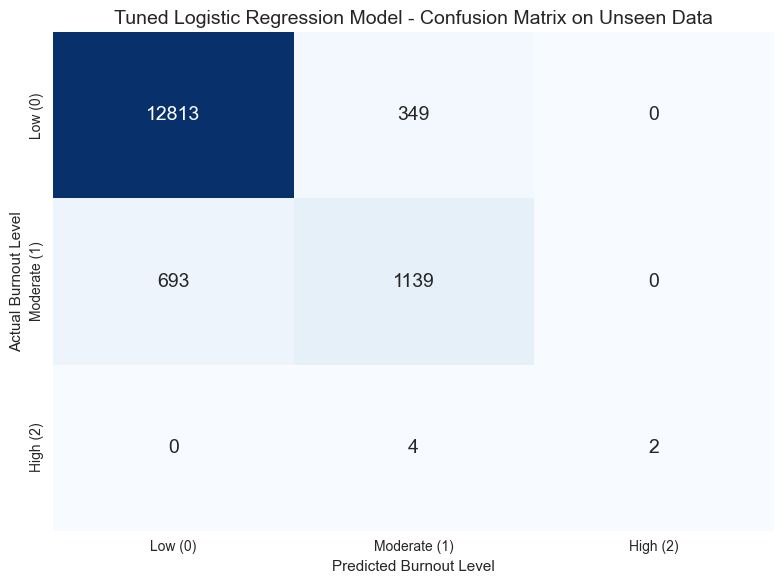

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_order = [0, 1, 2]
class_names = ['Low (0)', 'Moderate (1)', 'High (2)']

# Compute confusion matrix for the tuned Logistic Regression model
# on the completely unseen test dataset
cm_unseen = confusion_matrix(
    y_unseen,
    y_pred,
    labels=class_order
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_unseen,
    annot=True,
    annot_kws={'size': 14},
    fmt='g',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    'Tuned Logistic Regression Model - Confusion Matrix on Unseen Data',
    fontsize=14
)
plt.xlabel('Predicted Burnout Level')
plt.ylabel('Actual Burnout Level')

plt.tight_layout()
plt.show()

### Unseen Confusion Matrix Interpretation

The confusion matrix shows how the **tuned Logistic Regression model** performs across the three burnout classes on the completely unseen test dataset.

For the **Low-burnout class**, the model correctly classified **12,813 out of 13,162 cases**, while **349 cases were incorrectly classified as Moderate burnout**. This corresponds to a Recall of approximately **97.35%**, confirming that the model generalises very strongly for the majority Low-burnout class.

For the **Moderate-burnout class**, **1,139 out of 1,832 cases were correctly classified**, corresponding to a Recall of approximately **62.17%**. The main source of error was the misclassification of **693 Moderate-burnout cases as Low burnout**. No Moderate cases were incorrectly classified as High burnout. This shows that Moderate burnout remains more difficult for the model to distinguish from the dominant Low-burnout class.

For the rare **High-burnout class**, the model correctly identified **2 out of 6 cases**, while the remaining **4 cases were classified as Moderate burnout**. This produces a Recall of **33.33%**. However, both cases predicted as High burnout were correct, resulting in a Precision of **100%** for this class.

The High-burnout result should be interpreted cautiously because there are only **6 High-burnout observations** in the unseen test set. With such a small sample, even one additional correct or incorrect prediction would substantially change the class-level metrics.

Overall, the confusion matrix confirms that the tuned Logistic Regression model performs very strongly for **Low burnout**, provides moderate performance for **Moderate burnout**, but still has limited sensitivity for the extremely rare **High-burnout class**. This explains why the overall Accuracy remains high at **93.03%**, while the Macro F1-score is lower at **0.7154**. Therefore, the final model's performance should be assessed using the confusion matrix, class-level metrics and MCC together rather than relying on Accuracy alone.

## 8. Save and Reload the Final Model

The final trained PyCaret pipeline is saved so that it can be reused without repeating the complete model-training and tuning process.

In this portable team-project structure, `save_model()` writes the complete preprocessing and classification pipeline directly to `Kang Bin/employee_burnout_app/employee_burnout_final_model.pkl`. This is the same artefact loaded by the Flask Employee Burnout Predictor. The saved artefact is then loaded back and tested on a small sample of unseen predictor data to verify that the persisted pipeline can be restored successfully before it is logged and registered with MLflow.


In [40]:
# Save the complete final PyCaret preprocessing + classification pipeline
# directly into the Flask application folder used by the team portal.
saved_model_name = str(FINAL_MODEL_PATH)

save_model(
    final_model,
    saved_model_name
)


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['age', 'experience_years',
                                              'work_hours_per_week',
                                              'overtime_hours',
                                              'meetings_per_day',
                                              'deadlines_missed',
                                              'job_satisfaction',
                                              'manager_support',
                                              'work_life_balance', 'sleep_hours',
                                              'physical_activity_days',
                                              'screen_time_hours',
                                              'caffeine_intake',
                                              'social...
                                                          

### 8.1 Load and Validate the Saved Pipeline

The saved model is loaded from disk using PyCaret `load_model()`. A small sample from the unseen predictor data is then passed through both the original final pipeline and the reloaded pipeline. Matching predictions confirm that the saved artefact preserves the complete preprocessing and classification workflow correctly.


In [41]:
import numpy as np

# Load the pipeline that was saved in the previous step
loaded_final_pipeline = load_model(saved_model_name)

print("Loaded pipeline:")
display(loaded_final_pipeline)

# Test the reloaded pipeline on a small sample of raw unseen predictors
reload_test_input = X_unseen.head(5).copy()

original_reload_test_predictions = final_model.predict(reload_test_input)
loaded_reload_test_predictions = loaded_final_pipeline.predict(reload_test_input)

print("Original pipeline predictions:", original_reload_test_predictions)
print("Loaded pipeline predictions:  ", loaded_reload_test_predictions)

# Confirm that saving and loading did not change the predictions
assert np.array_equal(
    original_reload_test_predictions,
    loaded_reload_test_predictions
), "Reloaded pipeline predictions do not match the original final pipeline."

print()
print("Save/load validation passed: the reloaded pipeline reproduces the original predictions.")


Transformation Pipeline and Model Successfully Loaded
Loaded pipeline:


Pipeline(memory=FastMemory(location=C:\Users\KANGBI~1\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['age', 'experience_years',
                                             'work_hours_per_week',
                                             'overtime_hours',
                                             'meetings_per_day',
                                             'deadlines_missed',
                                             'job_satisfaction',
                                             'manager_support',
                                             'work_life_balance', 'sleep_hours',
                                             'physical_activity_days',
                                             's...
                                                                             75.0),
                                                             unit_variance=False,
                                                             with_centering=True,
                                                             with_scaling=True))),
                ('actual_estimator',
                 LogisticRegression(C=6.718000000000001, class_weight={},
                                    dual=False, fit_intercept=True,
                                    intercept_scaling=1, l1_ratio=None,
                                    max_iter=1000, multi_class='auto',
                                    n_jobs=None, penalty='l2', random_state=123,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

Original pipeline predictions: [0 0 0 0 0]
Loaded pipeline predictions:   [0 0 0 0 0]

Save/load validation passed: the reloaded pipeline reproduces the original predictions.


## 9. Log and Register the Final Model with MLflow

MLflow has already been enabled during PyCaret model development, satisfying the requirement to track experiments while models are being trained. After finalisation, unseen-data evaluation, and successful save/load validation, a separate named MLflow run is created specifically for the final deployable pipeline.

The **reloaded saved pipeline** is logged to MLflow together with the final unseen-data metrics, an input example, and a model signature. The same logging operation registers the model under the name `employee_burnout_classifier` in the MLflow Model Registry.

Before starting the dedicated final run, any PyCaret-created MLflow run that remains active in the current Python session is explicitly ended. This prevents the `Run ... is already active` error while preserving all previously logged training runs in the MLflow experiment history.


In [42]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Reconnect to the same local MLflow tracking server used during training
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("employee_burnout_classification")

# Name that will appear in the MLflow Model Registry
registered_model_name = "employee_burnout_classifier"

# Prepare a small example of the raw predictor data
input_example = X_unseen.head(5).copy()

# Generate example predictions from the successfully reloaded final pipeline
example_predictions = loaded_final_pipeline.predict(input_example)

# Infer the expected model input and output schema
signature = infer_signature(
    input_example,
    example_predictions
)

# PyCaret experiment logging can leave a run active in the current session.
# End only the active run context before creating the dedicated final run.
# Previously logged MLflow runs remain stored in the experiment history.
if mlflow.active_run() is not None:
    print(
        "Ending active PyCaret MLflow run before final registration:",
        mlflow.active_run().info.run_id
    )
    mlflow.end_run()

# Start a separate, clearly named run for the final registered model
with mlflow.start_run(run_name="Final Employee Burnout Model") as run:

    # Log final unseen-data evaluation metrics
    mlflow.log_metric("unseen_accuracy", float(accuracy))
    mlflow.log_metric("unseen_macro_f1", float(macro_f1))
    mlflow.log_metric("unseen_mcc", float(mcc))

    # Add descriptive metadata for traceability
    mlflow.set_tag(
        "Training Info",
        "Final saved-and-reloaded PyCaret employee burnout classification pipeline"
    )

    # Log and register the complete reloaded PyCaret pipeline
    model_info = mlflow.sklearn.log_model(
        sk_model=loaded_final_pipeline,
        artifact_path="employee_burnout_final_pipeline",
        signature=signature,
        input_example=input_example,
        registered_model_name=registered_model_name
    )

    print("MLflow model registration completed.")
    print("Run ID:", run.info.run_id)
    print("Model URI:", model_info.model_uri)
    print("Registered Model:", registered_model_name)


2026/08/21 23:29:58 INFO mlflow.tracking._tracking_service.client: 🏃 View run Session Initialized 0bf4 at: http://127.0.0.1:5000/#/experiments/478235090601148638/runs/bf6434ef331142e498fc5b709feba9fb.
2026/08/21 23:29:58 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/478235090601148638.


Ending active PyCaret MLflow run before final registration: bf6434ef331142e498fc5b709feba9fb


2026/08/21 23:30:11 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2024-09-26; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'backports-zstd'}
Successfully registered model 'employee_burnout_classifier'.
2026/08/21 23:30:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: employee_burnout_classifier, version 1
Created version '1' of model 'employee_burnout_classifier'.


2026/08/21 23:30:13 INFO mlflow.tracking._tracking_service.client: 🏃 View run Final Employee Burnout Model at: http://127.0.0.1:5000/#/experiments/478235090601148638/runs/b514439e443c4b74a7a309f2bb695803.
2026/08/21 23:30:13 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/478235090601148638.


MLflow model registration completed.
Run ID: b514439e443c4b74a7a309f2bb695803
Model URI: runs:/b514439e443c4b74a7a309f2bb695803/employee_burnout_final_pipeline
Registered Model: employee_burnout_classifier


### 9.1 Verify the Registered Model

The MLflow client is used to retrieve the registered model versions. A successful result confirms that the final model has been added to the MLflow Model Registry and assigned a version number.

In [43]:
from mlflow.tracking import MlflowClient

# Create a client connected to the configured MLflow tracking server
client = MlflowClient()

# Retrieve all versions registered under the final model name
model_versions = client.search_model_versions(
    f"name='{registered_model_name}'"
)

if not model_versions:
    raise RuntimeError(
        f"No registered versions found for '{registered_model_name}'. "
        "Check that the MLflow server is running and that the registration cell completed successfully."
    )

# Display the newest registered version first
model_versions = sorted(
    model_versions,
    key=lambda version: int(version.version),
    reverse=True
)

print("Registered Model:", registered_model_name)
print("Number of Registered Versions:", len(model_versions))
print()

for version in model_versions:
    print(
        f"Version: {version.version} | "
        f"Run ID: {version.run_id} | "
        f"Status: {version.status}"
    )

latest_version = model_versions[0]

print("\nLatest Registered Version:", latest_version.version)
print(
    "Model Registry URI:",
    f"models:/{registered_model_name}/{latest_version.version}"
)


Registered Model: employee_burnout_classifier
Number of Registered Versions: 1

Version: 1 | Run ID: b514439e443c4b74a7a309f2bb695803 | Status: READY

Latest Registered Version: 1
Model Registry URI: models:/employee_burnout_classifier/1


**Result:** MLflow experiment logging is enabled during PyCaret model development, so the training workflow is tracked in the `employee_burnout_classification` experiment. The final PyCaret pipeline is then trained using the retained dataset, evaluated on completely unseen data, saved, reloaded and validated before being logged in a separate named MLflow run and registered as `employee_burnout_classifier` in the MLflow Model Registry. The final unseen-data metrics, model artefact, signature and input example are associated with the dedicated final-model run.